# MULTIMODAL MUSIC ANALYSIS
## Team Members:
- Αλεξάνδρα Ζορμπά: 1115202200048
- Ιάσονας Καραπροδρομίδης: 1115202200064



# Part A: Preprocessing, Embeddings, and Exploratory Data Analysis (EDA)

# 1. Data Collection

### Downloads

In [17]:
!pip install gensim
!pip install vaderSentiment

### Imports

In [1]:
import os
import re
import tarfile
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
from ast import literal_eval
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Text embeddings imports
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.preprocessing import normalize

/home/jason/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Helper Functions

In [2]:
def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df

def find_id_column(columns):
    cols = [c.lower().strip() for c in columns]
    for c in ["id", "song_id", "track_id"]:
        if c in cols:
            return c
    raise ValueError(f"No id column found: {cols}")

def find_genre_column(columns):
    cols = [c.lower().strip() for c in columns]
    for c in ["genre", "genres", "label"]:
        if c in cols:
            return c
    raise ValueError(f"No genre column found: {cols}")

def clean_id_series(s):
    return s.astype(str).str.strip()

def normalize_label_text(x):
    x = str(x).strip().lower()

    # unify separators / spacing
    x = x.replace("&", "and")
    x = re.sub(r"[-_/]+", " ", x)      # hip-hop -> hip hop
    x = re.sub(r"\s+", " ", x).strip() # collapse repeated spaces

    # small controlled synonym mapping
    label_map = {
        "hiphop": "hip hop",
        "hip hop": "hip hop",
        "hip-hop": "hip hop",
        "rnb": "r&b",
        "r n b": "r&b",
        "rhythm and blues": "r&b",
    }

    return label_map.get(x, x)

def parse_genre_value(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [normalize_label_text(i) for i in x if str(i).strip()]

    x = str(x).strip()
    try:
        parsed = literal_eval(x)
        if isinstance(parsed, list):
            return [normalize_label_text(i) for i in parsed if str(i).strip()]
    except:
        pass

    return [normalize_label_text(p) for p in re.split(r"[;,|/]", x) if p.strip()]

### File Name Declarations

In [ ]:
FILES = {
    "genres": "/content/id_genres.csv",
    "audio": "/content/id_mfcc_stats.tsv.bz2",
    "lyrics": "/content/processed_lyrics.tar.gz",
}

### File Structure

In this step, a small sample (`nrows=5`) from each file is loaded to inspect:

- column names
- schema consistency
- data types / formatting

In [23]:
for name in ["genres"]:
    sample = normalize_columns(pd.read_csv(FILES[name], sep="\t", nrows=5))
    print(f"\n{name.upper()}")
    print(sample.columns.tolist())
    display(sample.head())

audio_sample = normalize_columns(
    pd.read_csv(FILES["audio"], sep="\t", compression="bz2", nrows=5)
)

print("\nAUDIO")
print(audio_sample.columns.tolist())
display(audio_sample.head())


GENRES
['id', 'genres']


,id,genres
0,0009fFIM1eYThaPg,pop
1,0010xmHR6UICBOYT,underground hip hop
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave"



AUDIO
['id', 'mfcc000', 'mfcc001', 'mfcc002', 'mfcc003', 'mfcc004', 'mfcc005', 'mfcc006', 'mfcc007', 'mfcc008', 'mfcc009', 'mfcc010', 'mfcc011', 'mfcc012', 'cov_0_0', 'cov_0_1', 'cov_0_2', 'cov_0_3', 'cov_0_4', 'cov_0_5', 'cov_0_6', 'cov_0_7', 'cov_0_8', 'cov_0_9', 'cov_0_10', 'cov_0_11', 'cov_0_12', 'cov_1_1', 'cov_1_2', 'cov_1_3', 'cov_1_4', 'cov_1_5', 'cov_1_6', 'cov_1_7', 'cov_1_8', 'cov_1_9', 'cov_1_10', 'cov_1_11', 'cov_1_12', 'cov_2_2', 'cov_2_3', 'cov_2_4', 'cov_2_5', 'cov_2_6', 'cov_2_7', 'cov_2_8', 'cov_2_9', 'cov_2_10', 'cov_2_11', 'cov_2_12', 'cov_3_3', 'cov_3_4', 'cov_3_5', 'cov_3_6', 'cov_3_7', 'cov_3_8', 'cov_3_9', 'cov_3_10', 'cov_3_11', 'cov_3_12', 'cov_4_4', 'cov_4_5', 'cov_4_6', 'cov_4_7', 'cov_4_8', 'cov_4_9', 'cov_4_10', 'cov_4_11', 'cov_4_12', 'cov_5_5', 'cov_5_6', 'cov_5_7', 'cov_5_8', 'cov_5_9', 'cov_5_10', 'cov_5_11', 'cov_5_12', 'cov_6_6', 'cov_6_7', 'cov_6_8', 'cov_6_9', 'cov_6_10', 'cov_6_11', 'cov_6_12', 'cov_7_7', 'cov_7_8', 'cov_7_9', 'cov_7_10', 'cov_7_

,id,mfcc000,mfcc001,mfcc002,mfcc003,mfcc004,mfcc005,mfcc006,mfcc007,mfcc008,...,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12
0,9EPCgcAlXdgiFsx4,20.640961,-5.828413,-6.140859,2.526664,-1.409552,2.681575,-2.989035,6.298501,3.528709,...,154.790424,21.799839,-15.056062,-19.218533,109.895439,26.262901,-4.037570,120.298222,18.571392,84.858156
1,9epP1yOXfLKlkR3S,24.351542,-16.611490,-10.792922,0.983246,-4.003687,-0.180248,-1.510487,-0.663130,2.915891,...,57.688839,20.511395,3.479626,-1.560816,63.036257,26.379835,2.551358,55.188890,18.194372,52.472903
2,9EPSUhPoRVOFU3WZ,20.963654,-10.754437,-17.771996,4.075799,-7.670935,7.884864,6.939635,-0.451056,1.786007,...,86.096650,21.553843,-21.785637,-28.995957,80.906525,15.235949,4.270046,92.649081,32.317742,94.037335
3,9eQ9CI53RilCiWe1,23.706192,-6.617346,-0.802629,-7.173328,-7.087190,1.222832,0.271057,5.402615,-1.984503,...,106.551662,27.140832,-25.204938,-15.030274,82.245596,6.003190,-0.670753,92.840371,31.832446,80.958201
4,9eQBXVI9m9OVpOzk,23.435280,-15.198643,-15.216316,6.386479,-1.970684,2.223027,3.663818,10.492731,3.448581,...,80.399399,27.589793,6.308148,-15.141247,81.638535,26.476400,-10.117312,70.432960,14.377084,68.796059


### Top-5 Genres

The five most frequent genres are identified based on occurrence counts in the genre metadata.

These top-5 genres are later used as the **primary target classes** for filtering and classification tasks.  
Genres outside this set are **not selected as target labels**, but they are still preserved in the original multi-genre metadata and may remain useful for exploratory analysis (e.g., genre overlap / tag information).

In [24]:
genre_counts = {}

sample = normalize_columns(pd.read_csv(FILES["genres"], sep="\t", nrows=5))
id_col_genres = find_id_column(sample.columns)
genre_col = find_genre_column(sample.columns)

for chunk in pd.read_csv(FILES["genres"], sep="\t", chunksize=50000):
    chunk = normalize_columns(chunk)
    chunk[id_col_genres] = clean_id_series(chunk[id_col_genres])
    chunk = chunk[[id_col_genres, genre_col]].dropna()

    for g in chunk[genre_col]:
        for gg in parse_genre_value(g):
            genre_counts[gg] = genre_counts.get(gg, 0) + 1

top5_genres = [g for g, _ in sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:5]]
print("Top-5 genres:", top5_genres)

Top-5 genres: ['rock', 'pop', 'electronic', 'alternative rock', 'indie rock']


### ID Filtering

The genre file is processed in chunks (`chunksize=50000`) to keep memory usage manageable.

For each chunk:
- the song ID column is cleaned and standardized
- all original genre tags are preserved in `genre_list_all`
- the subset of tags belonging to the selected top-5 genres is stored in `genre_list_top5`

A song is kept if it contains **at least one** of the selected top-5 genres.

For downstream single-label tasks (such as classification), one primary label is assigned in the `genre` column, taken as the first matching genre from `genre_list_top5`.

At the same time, the full multi-genre information is retained through:
- `genre_list_all`
- `genre_list_top5`
- `n_genres_all`
- `n_genres_top5`

This allows the notebook to support both:
- **single-label modelling**, and
- **multi-genre exploratory analysis** later on.

In [26]:
target_rows = []

for chunk in pd.read_csv(FILES["genres"], sep="\t", chunksize=50000):
    chunk = normalize_columns(chunk)
    chunk[id_col_genres] = clean_id_series(chunk[id_col_genres])

    # Keep the full original genre tags
    chunk["genre_list_all"] = chunk[genre_col].apply(parse_genre_value)

    # Keep only genres that belong to the selected top-5
    chunk["genre_list_top5"] = chunk["genre_list_all"].apply(
        lambda xs: [g for g in xs if g in top5_genres]
    )

    # Keep only songs that have at least one of the selected top-5 genres
    chunk = chunk[chunk["genre_list_top5"].apply(len) > 0].copy()

    # Single-label target used downstream for balancing / classification
    chunk["genre"] = chunk["genre_list_top5"].apply(lambda xs: xs[0])

    # Extra metadata for later analysis
    chunk["n_genres_all"] = chunk["genre_list_all"].apply(len)
    chunk["n_genres_top5"] = chunk["genre_list_top5"].apply(len)

    chunk = chunk[
        [
            id_col_genres,
            "genre",
            "genre_list_all",
            "genre_list_top5",
            "n_genres_all",
            "n_genres_top5",
        ]
    ].drop_duplicates(subset=[id_col_genres])

    target_rows.append(chunk)

genres_filtered = (
    pd.concat(target_rows, ignore_index=True)
    .drop_duplicates(subset=[id_col_genres])
    .reset_index(drop=True)
)

target_ids = set(genres_filtered[id_col_genres])

print("Songs kept:", len(target_ids))
display(genres_filtered.head())

Songs kept: 56100


,id,genre,genre_list_all,genre_list_top5,n_genres_all,n_genres_top5
0,0009fFIM1eYThaPg,pop,[pop],[pop],1,1
1,002Jyd0vN4HyCpqL,rock,"[hard rock, rock, classic rock]",[rock],3,1
2,00CH4HJdxQQQbJfu,indie rock,"[indie rock, experimental, shoegaze, experimen...",[indie rock],4,1
3,00DZ3XCAQb2FdCc6,electronic,"[ambient, easy listening, electronic]",[electronic],3,1
4,00IeldeA9ijZOL0P,pop,"[pop, disney]",[pop],2,1


Some songs may be associated with more than one genre in the original metadata.

For the purposes of the classification task, we keep one **primary genre label**
in the column `genre`, defined as the first genre from the song's genre list that
belongs to the selected top-5 set.

However, we also preserve the full genre information for later analysis:
- `genre_list_all`: all original genre tags
- `genre_list_top5`: only the tags that belong to the selected top-5 genres
- `n_genres_all`: number of original genre tags
- `n_genres_top5`: number of selected top-5 genre tags

This way, the notebook supports both single-label classification and later
multi-genre exploratory analysis without losing alignment.

### Load Lyrics - Display Structure


In [27]:
def load_lyrics(path, target_ids):
    rows = []
    with tarfile.open(path, "r:gz") as t:
        for m in t.getmembers():
            if m.isfile():
                song_id = Path(m.name).stem.strip()
                if song_id in target_ids:
                    f = t.extractfile(m)
                    if f is not None:
                        text = f.read().decode("utf-8", "ignore").strip()
                        rows.append({"id": song_id, "lyrics": text})
    return pd.DataFrame(rows).drop_duplicates(subset=["id"])

In [29]:
lyrics_df = load_lyrics(FILES["lyrics"], target_ids)
print("Lyrics:", len(lyrics_df))
display(lyrics_df.head())

Lyrics: 56100


,id,lyrics
0,9jbSytob9XRzwvB6,deep feel heart burn deep insid yearn know com...
1,Njp6JPM8vitbhVJU,noth hurt like pain someon love noth gain prep...
2,h48f46ZsT9h0Z5Dm,arm side heart sleev chandeli fall stand under...
3,kVtduoU5M56Amw1M,ladi ladi ladi ladi power ladi ladi ladi ladi ...
4,edfqrL2UN8OfrmhP,blow want hold hand tell puls constant distant...


### Load Audio - Display Structure

In [30]:
audio_sample = normalize_columns(
    pd.read_csv(FILES["audio"], sep="\t", compression="bz2", nrows=5)
)

audio_id_col = find_id_column(audio_sample.columns)
mfcc_cols = audio_sample.columns.drop(audio_id_col)

audio_parts = []
for chunk in pd.read_csv(FILES["audio"], sep="\t", compression="bz2", chunksize=50000):
    chunk = normalize_columns(chunk)
    chunk[audio_id_col] = clean_id_series(chunk[audio_id_col])
    chunk = chunk[chunk[audio_id_col].isin(target_ids)].copy()

    chunk["mfcc_stats"] = chunk[mfcc_cols].values.tolist()
    chunk = chunk[[audio_id_col, "mfcc_stats"]].rename(columns={audio_id_col: "id"})
    audio_parts.append(chunk)

audio_df = pd.concat(audio_parts, ignore_index=True).drop_duplicates(subset=["id"])

print("Audio:", len(audio_df))
display(audio_df.head())

Audio: 56100


,id,mfcc_stats
0,9EPCgcAlXdgiFsx4,"[20.64096069335937, -5.828413009643555, -6.140..."
1,9epP1yOXfLKlkR3S,"[24.35154151916504, -16.61149024963379, -10.79..."
2,9EPSUhPoRVOFU3WZ,"[20.963653564453125, -10.754437446594238, -17...."
3,9eQBXVI9m9OVpOzk,"[23.43527984619141, -15.19864273071289, -15.21..."
4,9eQeRq6A9wBpfrhL,"[23.8997802734375, -2.7487893104553223, -7.556..."


### Merge Lyrics and Audio

In [46]:
genres_final = genres_filtered.rename(columns={id_col_genres: "id"}).copy()

genres_final["id"] = clean_id_series(genres_final["id"])
lyrics_df["id"] = clean_id_series(lyrics_df["id"])
audio_df["id"] = clean_id_series(audio_df["id"])

common_ids = set(genres_final["id"]) & set(lyrics_df["id"]) & set(audio_df["id"])

df_multimodal = (
    genres_final[genres_final["id"].isin(common_ids)]
    .merge(lyrics_df, on="id", how="inner")
    .merge(audio_df, on="id", how="inner")
    .drop_duplicates(subset=["id"])
    .reset_index(drop=True)
)

print(df_multimodal.shape)
display(df_multimodal.head())

(56100, 8)


,id,genre,genre_list_all,genre_list_top5,n_genres_all,n_genres_top5,lyrics,mfcc_stats
0,0009fFIM1eYThaPg,pop,[pop],[pop],1,1,sunni day get nowher hide cloud sky pretend ge...,"[23.622419357299805, -14.43531894683838, -7.96..."
1,002Jyd0vN4HyCpqL,rock,"[hard rock, rock, classic rock]",[rock],3,1,goer phone freiburg say willi do quit job hitl...,"[22.90932273864746, -7.674675464630128, -19.89..."
2,00CH4HJdxQQQbJfu,indie rock,"[indie rock, experimental, shoegaze, experimen...",[indie rock],4,1,crimin walk room ask live way think could woul...,"[23.43621063232422, -7.816750049591064, -12.40..."
3,00DZ3XCAQb2FdCc6,electronic,"[ambient, easy listening, electronic]",[electronic],3,1,,"[24.70748710632324, -4.001090049743652, -5.915..."
4,00IeldeA9ijZOL0P,pop,"[pop, disney]",[pop],2,1,yeah yeah love alway find way everi singl time...,"[21.56878089904785, -13.38962173461914, -8.882..."


### Balanced Sampling
Produce Balanced dataset with 5000-10000 records

To ensure a balanced and computationally manageable dataset, we performed stratified random sampling by genre. Specifically, we limited the number of samples per genre to a fixed threshold (target_per_genre = min(genre.value_counts())), resulting in an overall dataset size within the desired range (5,000-10,000 samples).

Instead of using a fixed random seed for all groups, we utilized a random number generator to assign different seeds to each genre during sampling. This approach preserves reproducibility while avoiding identical sampling patterns across groups, leading to a more representative and unbiased subset of the data.

### Dataset Filtering Policy

Songs with missing or empty lyrics were removed from the final dataset.

Reason:
- Text embeddings require valid textual input.
- Later multimodal fusion requires aligned audio + text samples.
- Using complete rows ensures fair comparison between modalities.

This may exclude some audio-only songs, but guarantees consistency across experiments.

In [47]:
# Remove empty / missing lyrics FIRST
df_multimodal = df_multimodal[df_multimodal["lyrics"].notna()]
df_multimodal = df_multimodal[df_multimodal["lyrics"].str.strip() != ""].copy()

# Balanced sampling
target_per_genre = df_multimodal["genre"].value_counts().min()

df_multimodal = (
    df_multimodal
    .groupby("genre", group_keys=False)
    .sample(n=target_per_genre, random_state=42)
    .reset_index(drop=True)
)

### Produce clear CSV with final songs

In [ ]:
df_multimodal.to_csv("/content/final_dataset.csv", index=False)
print("Saved: /content/final_dataset.csv")

Saved: /content/final_dataset.csv


# 2. Feature Extraction

## 2.1 Text embeddings

A manual inspection revealed that the lyrics are in English, allowing us to directly apply pre-trained English language models without additional language-specific preprocessing.

### Convert lyrics into token lists

The lyrics are already preprocessed, so we only perform lightweight tokenization
by splitting on whitespace. These token lists will be used to train a Word2Vec
model and to construct one dense vector per song via mean pooling.

In [ ]:
# Load the dataset
df_features = pd.read_csv("/content/final_dataset.csv")

df_features["tokens"] = (
    df_features["lyrics"]
    .astype(str)
    .str.split()
)

# Remove rows with extremely short token lists
df_features = df_features[df_features["tokens"].apply(len) >= 3].reset_index(drop=True)

print("Shape:", df_features.shape)
display(df_features[["id", "genre", "genre_list_top5", "n_genres_top5", "tokens"]].head())

Shape: (17449, 9)


,id,genre,genre_list_top5,n_genres_top5,tokens
0,4xwkJn8oa6sPqCwm,alternative rock,['alternative rock'],1,"[never, meet, mom, string, never, attach, alwa..."
1,tw0SUf3c4NeaqPFh,alternative rock,['alternative rock'],1,"[say, love, curs, write, sonnet, end, say, lov..."
2,y0SNXnC7zksqDVXB,alternative rock,['alternative rock'],1,"[know, know, make, dream, much, make, dream, m..."
3,P8lZcyOmOvfXUDuI,alternative rock,"['alternative rock', 'rock']",2,"[feel, like, well, day, pass, bet, well, best,..."
4,GZ8upi4wcJg2sT6Q,alternative rock,"['alternative rock', 'indie rock']",2,"[composit, rodrigo, amarant, discov, world, ge..."


Songs with fewer than 3 lyric tokens were removed before feature extraction, and all subsequent text and audio embeddings are computed on this common filtered subset.

### Train a Word2Vec model on the lyrics corpus

We train Word2Vec on the tokenized lyrics corpus. Then, for each song, we create
a single fixed-length embedding by averaging the vectors of the words that
appear in the song.

In [50]:
sentences = df_features["tokens"].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,          # skip-gram
    epochs=15,
    seed=42
)

print("Vocabulary size:", len(w2v_model.wv))
print("Embedding dimension:", w2v_model.vector_size)

Vocabulary size: 17077
Embedding dimension: 100


### Build one embedding per song using mean pooling

For each song, we average the word vectors of all tokens that exist in the
Word2Vec vocabulary. This gives one dense vector representation per song.

In [51]:
def mean_word2vec_embedding(tokens, model):
    valid_vectors = [model.wv[token] for token in tokens if token in model.wv]

    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size, dtype=np.float32)

    return np.mean(valid_vectors, axis=0)

text_emb_w2v = np.vstack(
    df_features["tokens"].apply(lambda toks: mean_word2vec_embedding(toks, w2v_model)).values
)

print("Word2Vec song-embedding matrix shape:", text_emb_w2v.shape)

Word2Vec song-embedding matrix shape: (17449, 100)


In [52]:
# put embeddings in a DataFrame for easier inspection / saving
w2v_cols = [f"w2v_{i}" for i in range(text_emb_w2v.shape[1])]

text_emb_w2v_df = pd.DataFrame(
    text_emb_w2v,
    columns=w2v_cols,
    index=df_features['id'] # Sets the index immediately
)

display(text_emb_w2v_df.head())

,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_90,w2v_91,w2v_92,w2v_93,w2v_94,w2v_95,w2v_96,w2v_97,w2v_98,w2v_99
id,,,,,,,,,,,,,,,,,,,,,
4xwkJn8oa6sPqCwm,-0.021939,0.069609,-0.225644,0.087985,-0.098649,0.092485,-0.114785,0.057710,-0.047367,0.025797,...,-0.361043,0.309800,0.157543,-0.314890,0.308062,-0.066098,-0.113681,0.467286,0.003970,-0.075098
tw0SUf3c4NeaqPFh,0.080318,0.179239,-0.150548,0.036320,-0.102305,0.123184,0.139012,0.160845,-0.212842,-0.130500,...,-0.283886,0.299320,0.148435,-0.242353,0.264714,-0.204302,-0.026958,0.268456,0.136319,-0.115715
y0SNXnC7zksqDVXB,0.062604,0.193965,-0.249047,0.041358,-0.207754,0.085497,0.084294,0.193042,-0.172769,-0.097279,...,-0.340701,0.231750,0.020315,-0.249094,0.283418,-0.231462,-0.010407,0.179128,0.025808,-0.035560
P8lZcyOmOvfXUDuI,0.104548,0.239492,-0.114636,0.083728,-0.116526,0.196798,0.008561,0.211928,-0.215725,-0.064483,...,-0.239732,0.307630,0.088426,-0.235652,0.153350,-0.207524,-0.034864,0.242673,0.122646,-0.059147
GZ8upi4wcJg2sT6Q,0.040164,0.061943,-0.343131,0.046832,-0.153950,0.106256,0.143244,0.170075,-0.319809,-0.161459,...,-0.426736,0.307993,0.156715,-0.359975,0.260141,-0.119065,0.021271,0.147889,0.004801,-0.047842


### 2.1.2 Bonus: Pre-trained sentence embeddings with Sentence-BERT

As a stronger semantic baseline, we also extract sentence-level embeddings using
a pre-trained transformer model. Unlike Word2Vec, this approach captures richer
contextual information at the full-song level.

In [53]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

text_emb_sbert = sbert_model.encode(
    df_features["lyrics"].astype(str).tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("SBERT embedding matrix shape:", text_emb_sbert.shape)

Batches: 100%|██████████| 546/546 [06:45<00:00,  1.35it/s]

SBERT embedding matrix shape: (17449, 384)


In [54]:
sbert_cols = [f"sbert_{i}" for i in range(text_emb_sbert.shape[1])]

text_emb_sbert_df = pd.DataFrame(
    text_emb_sbert,
    columns=sbert_cols,
    index=df_features['id'] # Sets the index immediately
)

display(text_emb_sbert_df.head())

,sbert_0,sbert_1,sbert_2,sbert_3,sbert_4,sbert_5,sbert_6,sbert_7,sbert_8,sbert_9,...,sbert_374,sbert_375,sbert_376,sbert_377,sbert_378,sbert_379,sbert_380,sbert_381,sbert_382,sbert_383
id,,,,,,,,,,,,,,,,,,,,,
4xwkJn8oa6sPqCwm,-0.072793,-0.063335,0.044756,0.025606,-0.088553,0.025148,0.111832,0.007149,0.011213,-0.020018,...,0.026731,-0.000514,0.020812,0.111816,-0.005699,-0.033345,0.027948,0.033757,0.000027,-0.046852
tw0SUf3c4NeaqPFh,-0.065641,-0.046710,0.048470,-0.002813,-0.073570,0.067611,0.082799,-0.094226,0.072974,-0.035759,...,0.082910,0.037922,-0.012883,0.088314,-0.011183,0.004775,0.038770,0.031548,0.051820,-0.083193
y0SNXnC7zksqDVXB,0.050119,-0.032843,0.015745,0.057252,-0.012368,0.032219,0.093440,-0.028842,0.029657,-0.069778,...,0.085579,0.032577,-0.032839,0.104386,-0.021348,-0.037129,-0.003962,0.000548,-0.025159,-0.065944
P8lZcyOmOvfXUDuI,-0.107372,-0.032745,0.054414,0.028052,-0.036108,0.040777,0.121143,-0.046601,0.030099,-0.036905,...,0.013217,0.099815,-0.018039,0.077148,-0.055088,-0.006188,0.041717,0.006925,0.037783,-0.031085
GZ8upi4wcJg2sT6Q,-0.073900,-0.059852,-0.011241,-0.014518,-0.079693,0.042938,0.123293,0.001405,0.072866,0.047488,...,0.079889,-0.042140,0.027363,0.077414,-0.093944,0.025328,0.006996,-0.038117,-0.008185,0.028212


## 2.2 Audio embeddings

The MFCC statistics are high-dimensional and potentially noisy. Therefore, we
first reconstruct them as a numeric matrix and then apply PCA to obtain a more
compact audio embedding while retaining 95% of the variance.

In [13]:
from ast import literal_eval

def ensure_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return literal_eval(x)
    return x

df_features["mfcc_stats"] = df_features["mfcc_stats"].apply(ensure_list)

X_audio = np.array(df_features["mfcc_stats"].tolist(), dtype=np.float32)

print(X_audio.shape)

(17449, 104)


In [56]:
print("Raw audio feature matrix shape:", X_audio.shape)
print("Any NaNs?", np.isnan(X_audio).any())

Raw audio feature matrix shape: (17449, 104)
Any NaNs? False


In [57]:
# Impute missing values if any
imputer = SimpleImputer(strategy="mean")
X_audio_imp = imputer.fit_transform(X_audio)

# Standardization before PCA
scaler_audio = StandardScaler()
X_audio_scaled = scaler_audio.fit_transform(X_audio_imp)

print("Scaled audio matrix shape:", X_audio_scaled.shape)

Scaled audio matrix shape: (17449, 104)


### PCA-based audio embeddings

We apply PCA and keep enough principal components to preserve 95% of the total
variance. The resulting vectors are the compact audio embeddings used in the
next parts of the assignment.

In [58]:
pca_audio = PCA(n_components=0.95, random_state=42)
audio_emb_pca = pca_audio.fit_transform(X_audio_scaled)

print("Audio PCA embedding matrix shape:", audio_emb_pca.shape)
print("Explained variance ratio sum:", pca_audio.explained_variance_ratio_.sum())
print("Number of retained components:", pca_audio.n_components_)

Audio PCA embedding matrix shape: (17449, 80)
Explained variance ratio sum: 0.95085466
Number of retained components: 80


In [59]:
audio_cols = [f"audio_pca_{i}" for i in range(audio_emb_pca.shape[1])]

audio_emb_pca_df = pd.DataFrame(
    audio_emb_pca,
    columns=audio_cols,
    index=df_features['id'] # Sets the index immediately
)

display(audio_emb_pca_df.head())

,audio_pca_0,audio_pca_1,audio_pca_2,audio_pca_3,audio_pca_4,audio_pca_5,audio_pca_6,audio_pca_7,audio_pca_8,audio_pca_9,...,audio_pca_70,audio_pca_71,audio_pca_72,audio_pca_73,audio_pca_74,audio_pca_75,audio_pca_76,audio_pca_77,audio_pca_78,audio_pca_79
id,,,,,,,,,,,,,,,,,,,,,
4xwkJn8oa6sPqCwm,-1.730645,-1.889467,-0.916749,-0.172282,0.826774,-0.873344,-0.211064,0.561844,-0.489501,0.531817,...,0.020489,-0.043023,-0.130651,-0.183966,0.029039,-0.055882,0.184101,-0.219691,-0.005279,-0.095235
tw0SUf3c4NeaqPFh,-3.376871,-0.757737,0.503649,0.957855,0.912704,0.392874,0.031572,-0.068383,0.394864,1.429500,...,-0.416913,0.003219,-0.562695,0.074000,0.016790,-0.161338,-0.691450,-0.048657,0.776727,-0.203479
y0SNXnC7zksqDVXB,-3.778114,-2.594917,-2.596172,-2.894673,-1.448534,-0.012188,0.999100,-0.660498,-0.381682,1.597688,...,0.087661,0.064584,0.071835,0.454432,-0.290208,0.041345,0.146989,-0.029947,-0.013649,-0.334610
P8lZcyOmOvfXUDuI,-1.617169,1.127044,1.975421,-0.564958,-1.442763,0.075828,0.853084,-0.304153,-0.211037,0.277309,...,-0.647486,0.313595,0.275712,-0.222287,-0.077998,-0.376622,0.436220,-0.110856,-0.211351,-0.073313
GZ8upi4wcJg2sT6Q,-2.180819,2.203021,2.685107,-1.796348,4.279112,-0.473383,1.461637,2.805635,-3.023472,-3.118351,...,0.273034,-0.074068,-0.160597,0.168422,-0.076083,0.826546,0.062972,0.472085,0.301935,-0.050978


## 2.3 Save the extracted feature matrices

We save the text and audio embedding tables so they can be reused in later
experiments without retraining or recomputing the representations.

In [ ]:
text_emb_w2v_df.to_csv("/content/text_embeddings_word2vec.csv", index=True)
text_emb_sbert_df.to_csv("/content/text_embeddings_sbert.csv", index=True)
audio_emb_pca_df.to_csv("/content/audio_embeddings_pca.csv", index=True)

print("Saved:")
print("- /content/text_embeddings_word2vec.csv")
print("- /content/text_embeddings_sbert.csv")
print("- /content/audio_embeddings_pca.csv")

Saved:
- /content/text_embeddings_word2vec.csv
- /content/text_embeddings_sbert.csv
- /content/audio_embeddings_pca.csv


## Short interpretation

We now have:
- a Word2Vec-based text embedding matrix,
- a transformer-based text embedding matrix (bonus),
- a PCA-compressed audio embedding matrix.

These representations will be used in the next section for visualization,
similarity analysis, and later classification experiments.

The Word2Vec model was trained directly on the lyrics corpus and produced one
dense vector per song through mean pooling of token embeddings. In parallel, we
used a pre-trained Sentence-BERT model to obtain richer semantic song-level
embeddings. For the audio modality, the original MFCC statistics were
standardized and compressed with PCA, retaining 95% of the variance. These
three feature tables form the basis for the downstream EDA and classification
tasks.

# 3. Exploratory Data Analysis (EDA)

## Word Clouds for 2 most different genres

In [ ]:
def clean_tags(tag_string):
    if not tag_string: return ""
    # Split by comma, strip whitespace, lowercase, and keep unique items
    tags = set(t.strip().lower() for t in tag_string.split(','))
    return ", ".join(tags)


df_tags = pd.read_csv("/content/id_tags.csv", sep='\t', names=['id', 'tags'])
df_features = df_features.merge(df_tags, on='id', how='left')
df_features['tags'] = df_features['tags'].apply(clean_tags)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 7.9 MB/s eta 0:00:00:00:010:01
Selected genres: alternative rock vs pop


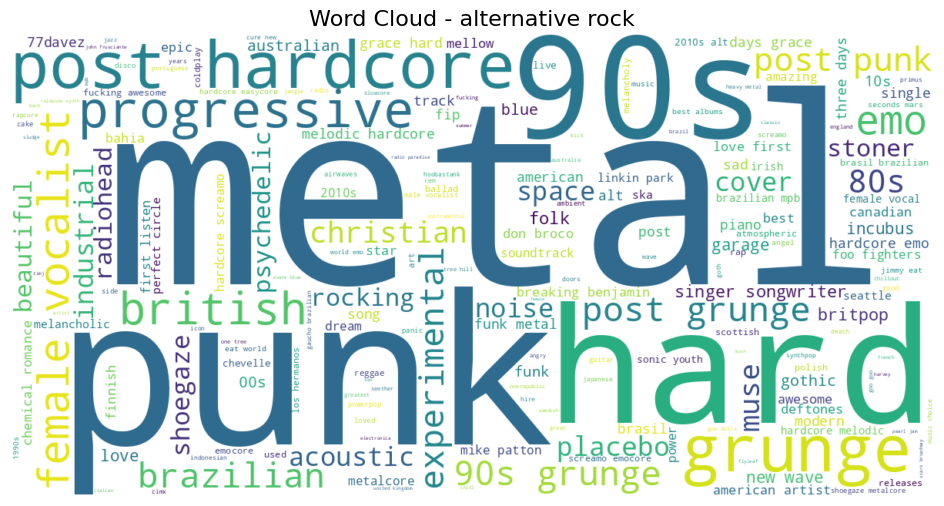

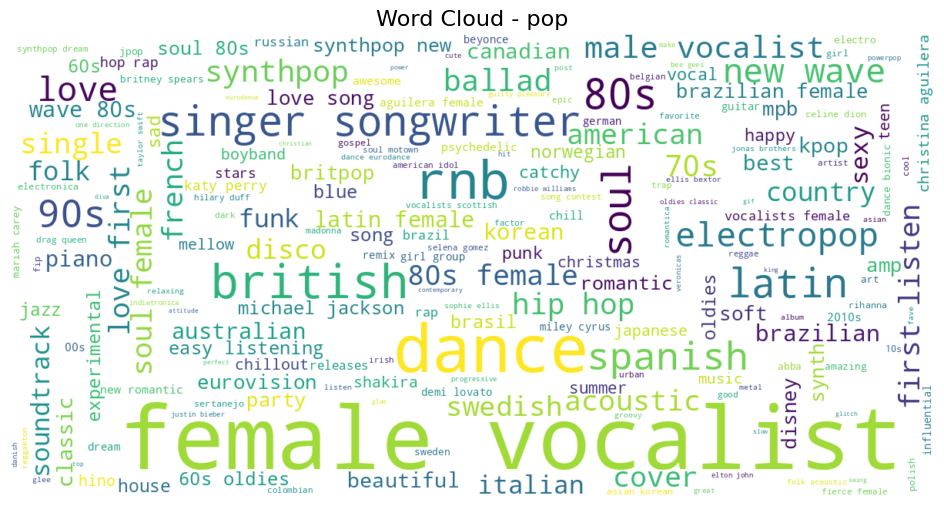

In [62]:
!pip install wordcloud

from wordcloud import WordCloud
from wordcloud import STOPWORDS

# choose two genres
target_genre1 = 'alternative rock'
target_genre2 = 'pop'

print("Selected genres:", target_genre1, "vs", target_genre2)
my_stopwords = set(STOPWORDS)
my_stopwords.add("pop")
my_stopwords.add("rock")
my_stopwords.add("alternative")
my_stopwords.add("indie")
my_stopwords.add("electronic")
for g in [target_genre1, target_genre2]:

    text = " ".join(df_features[df_features["genre"] == g]["tags"].astype(str))

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        colormap="viridis",
        stopwords=my_stopwords, # This removes boring words like 'the', 'is', 'at'
        min_word_length=3    # Filters out 'oh', 'ah', 'ye'
    ).generate(text)

    plt.figure(figsize=(14,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {g}", fontsize=16)
    plt.show()

## Case study: POP vs Alternative Rock

As this wordcloud shows (and as we expected) alternative rock is described by words like Metal, hard, hardcore, noise, emo etc. While POP is described with more mellow words, and generally more "happy" words, like dance, love, sexy, soft etc. This highlights the differences of these two genres with one POP being more chill and happy, with alternative rock being more edgy and towards sadness and anger, and one appeals to the masses where one appeals to a specific demographic, which is why we see a lot more similar words for alternative rock because it is more focused in being "Hard". The Alt Rock word cloud feels more "uniform" and aggressive, it's a genre defined by its intensity and specific technical boundaries, whereas Pop is a "big tent" that borrows from everywhere, leading to a more scattered vocabulary.



## Top 10 most common Tags per Genre

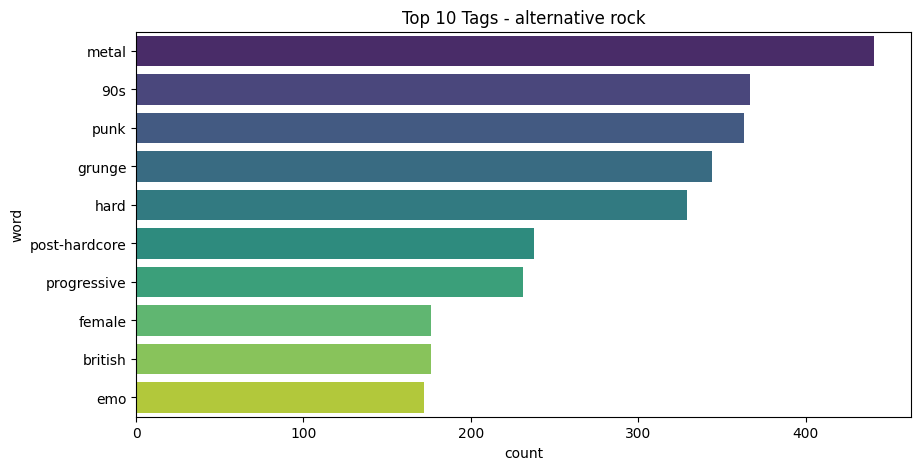

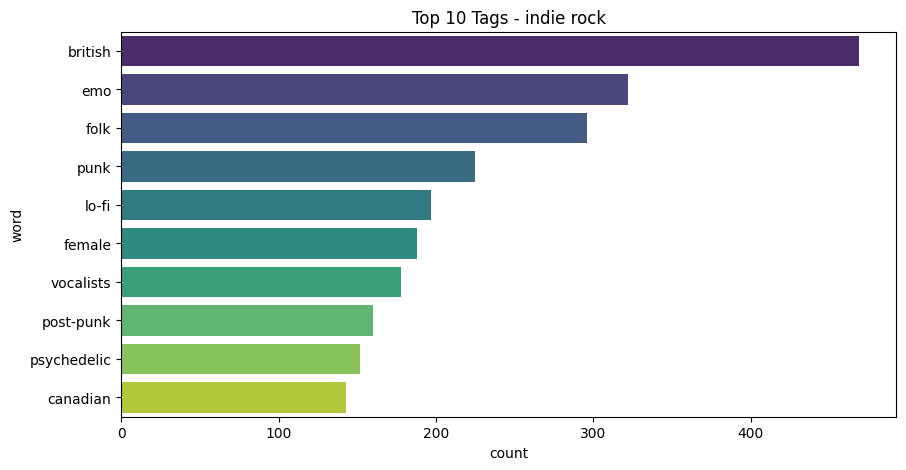

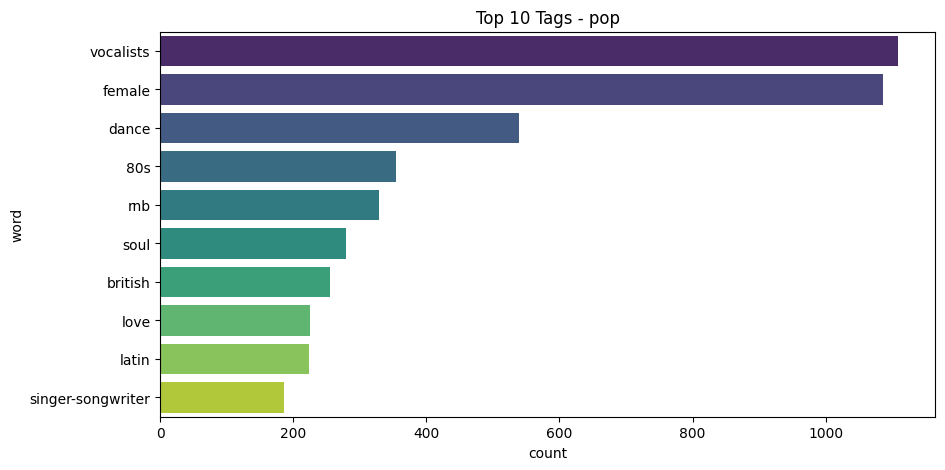

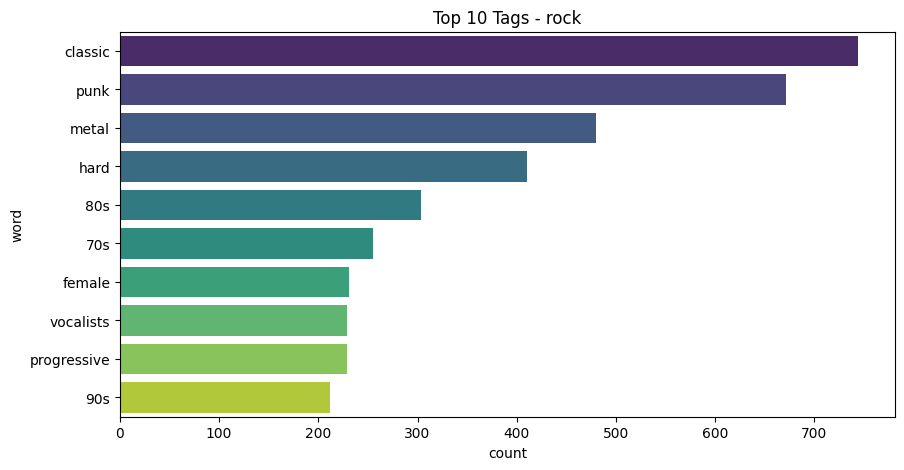

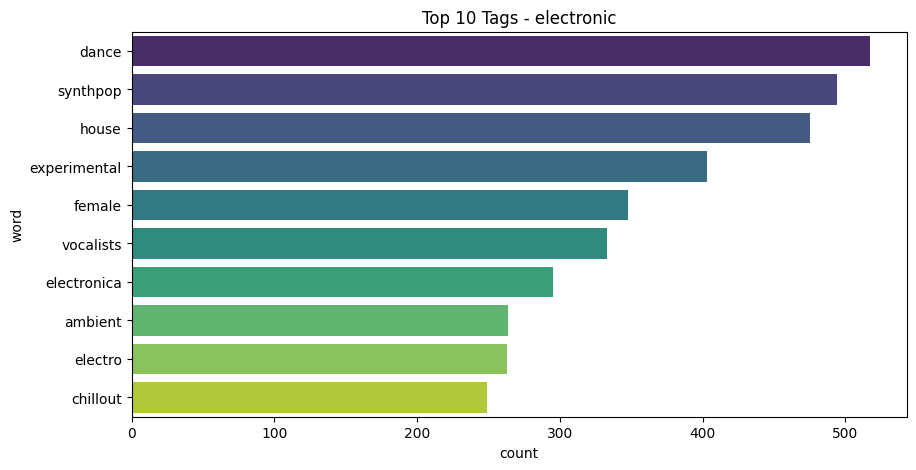

In [63]:
from collections import Counter
import seaborn as sns


top_genres = df_features["genre"].value_counts().index.tolist()

for g in top_genres:
    raw_text = " ".join(df_features[df_features["genre"] == g]["tags"].astype(str)).lower().split()

    # Keep only words NOT in your stopword list
    # We also strip punctuation like commas if they are attached to words
    text = [word.strip(',') for word in raw_text if word.strip(',') not in my_stopwords]

    common = Counter(text).most_common(10)

    temp = pd.DataFrame(common, columns=["word","count"])

    plt.figure(figsize=(10,5))
    sns.barplot(data=temp, x="count", y="word", palette="viridis", hue='word', legend=False)
    plt.title(f"Top 10 Tags - {g}")
    plt.show()

## Analysis
### The rock effect
All three rock genres analysed here show a clear pattern of being characterized with hard words such as metal, hard, grunge etc. It also shows that there is a specific focus on the era the songs were made in, with 70s, 80s, 90s being present in both alternative and classic Rock. Indie Rock breaks this mold, it is less about the decade and more about geography (British, Canadian) and emotion (Emo, Folk). It is a "moodier," more regional genre compared to the stadium-filling tags of Classic Rock
### POP
The Pop section is the most distinct because it is defined by identity and emotion rather than instrumentals.


*   Vocal Dominance: The top tags (Vocalists, Female) suggest that Pop is viewed as a "singer's genre." While you noted the visual aspect, the data specifically highlights R&B and Soul as major sub-influences. This shows that "Pop" in this dataset isn't just "bubblegum" music; it has deep roots in soulful, vocal-heavy traditions.

*   The "Human" Element: Unlike Electronic music, which is tagged by tech (synth, house), Pop is tagged by people and feelings (Love, Singer-Songwriter). This indicates that the audience connects more with the storyteller than the production

### Electronic
Electronic music seems to be characterized by its sound, with tags like synthpop, experimental and house, and also dance which is a major focus of this genre. This genre is very frequently played in clubs and has very little lyrics, so the focus is on how it sounds and not on who is producing it.

### Some common ground


1.   The UK factor: The tag british appears in POP, alternative rock and indie rock, showing that british songwriters have a very strong influence in the music industry.
2.   The female factor: The female tag is present everywhere except classic Rock. This indicates that listeners focus on the gender of the singer across all genres.
3.   Punk appears in the top tags for Rock, Alt Rock, and Indie Rock. This suggests that Punk is the "DNA" of modern guitar music. It acts as the bridge that connects the old-school Rock of the 70s to the Indie/Alt scenes of today.



## PCA / t-SNE on Text Embeddings

In [ ]:
df_lyrics = pd.read_csv("/content/text_embeddings_sbert.csv", index_col=0)
df_audio = pd.read_csv("/content/audio_embeddings_pca.csv", index_col=0)

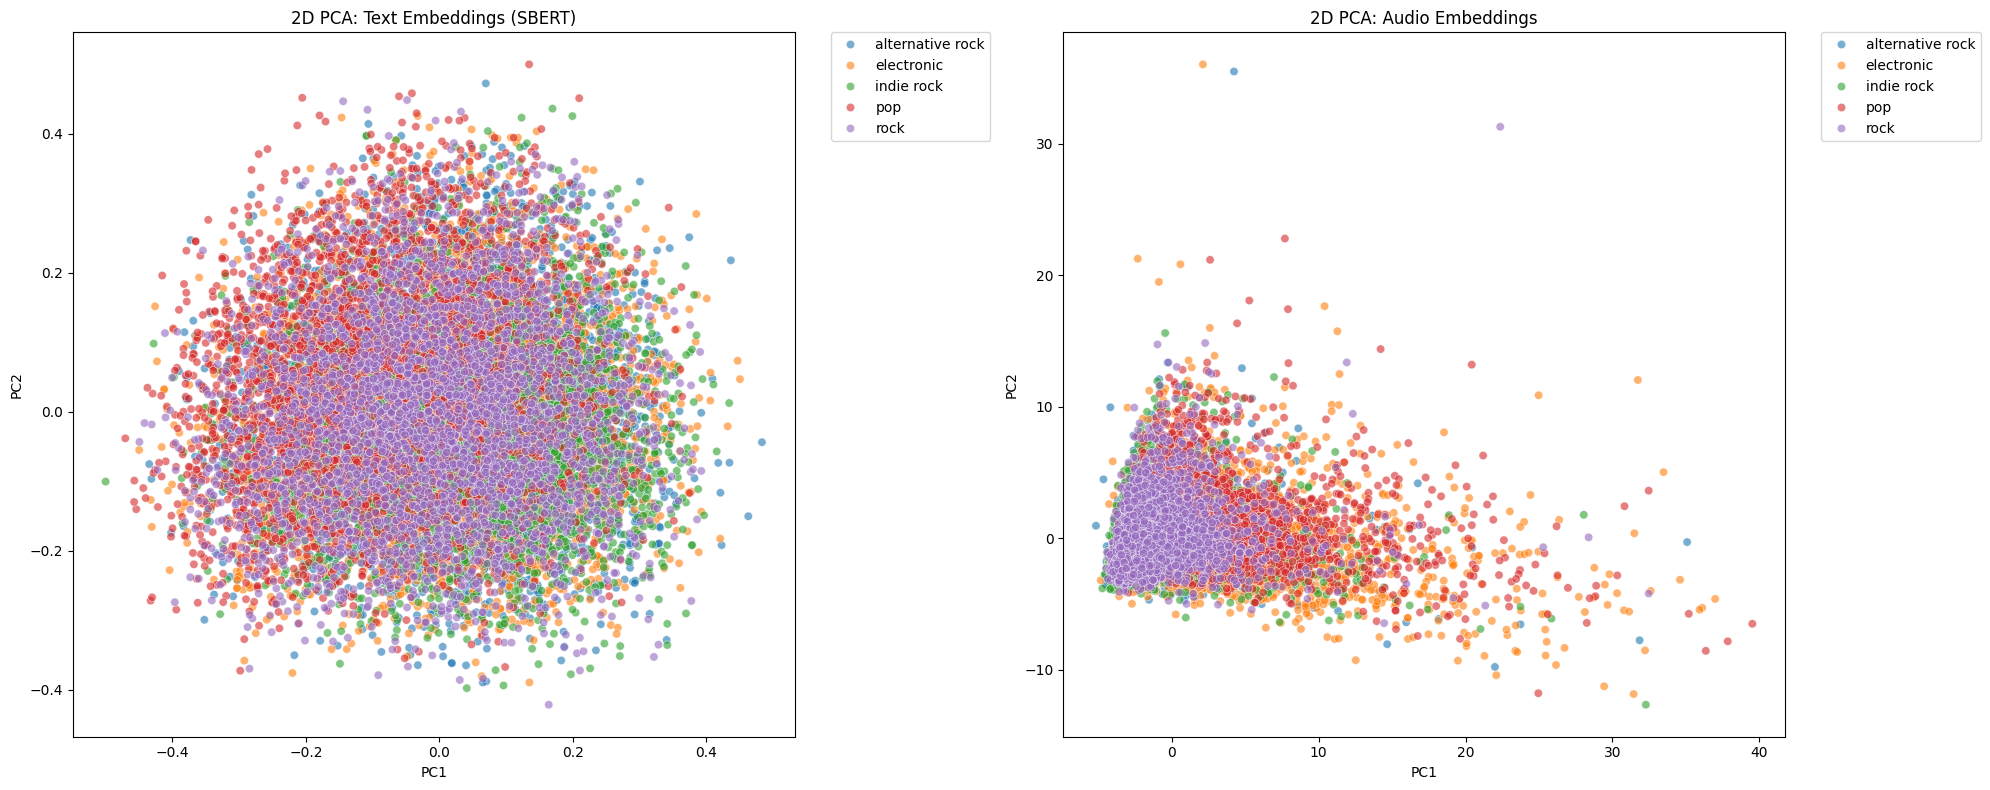

In [65]:
pca = PCA(n_components=2)

# Transform Text
text_2d = pca.fit_transform(df_lyrics)
df_text_pca = pd.DataFrame(text_2d, columns=['PC1', 'PC2'])
df_text_pca['genre'] = df_features['genre'].values

# Transform Audio
audio_2d = pca.fit_transform(df_audio)
df_audio_pca = pd.DataFrame(audio_2d, columns=['PC1', 'PC2'])
df_audio_pca['genre'] = df_features['genre'].values

# 4. Create the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Text Plot
sns.scatterplot(data=df_text_pca, x='PC1', y='PC2', hue='genre', ax=ax1, palette='tab10', alpha=0.6)
ax1.set_title("2D PCA: Text Embeddings (SBERT)")
ax1.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Audio Plot
sns.scatterplot(data=df_audio_pca, x='PC1', y='PC2', hue='genre', ax=ax2, palette='tab10', alpha=0.6)
ax2.set_title("2D PCA: Audio Embeddings")
ax2.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.tight_layout()
plt.show()

### Did any clusters from?
After analyzing the data with both PCA and t-SNE, I found that PCA actually gave me something I could work with, while t-SNE didn't really show anything of value for these embeddings.

Looking at the Text Embeddings (SBERT) graph, the lyrics basically just form one big cloud. There aren't any real clusters, which makes sense since we've already seen how much different genres share the same vocabulary. However, you can see a slight pattern where Pop and Indie Rock sit on opposite sides of the spectrum. Rock generally stays in the middle, while Alternative Rock and Electronic just blend in with everything else without forming their own distinct groups.

The Audio Embeddings are much more interesting and tell a better story. While the three Rock genres still overlap a lot in the center, Pop and Electronic music start to pull away toward a much higher PC1 dimension. This shows that those genres have a specific "sound" that the model can actually separate from the rest.

### Which modality seems to categorize genres better?
In the end, this visualizes exactly what I found in my case study: audio embeddings are just better at distinguishing between genres. It's a lot easier to tell a genre by its sound than by its lyrics, which tend to stay quite close regardless of the style.

## Genre Multiplicity per Song

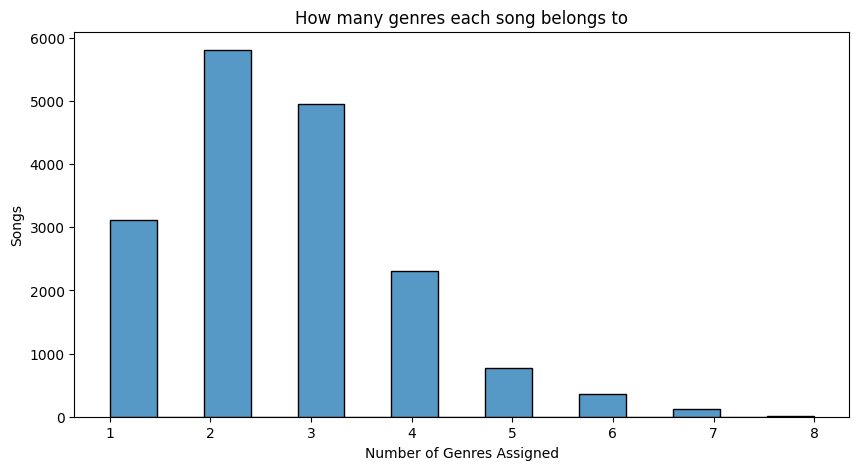

In [66]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_features["n_genres_all"],
    bins=15
)

plt.xlabel("Number of Genres Assigned")
plt.ylabel("Songs")
plt.title("How many genres each song belongs to")
plt.show()

### Proof it is difficult to rank a song in only 1 genre
Looking at the distribution, most songs in the dataset are assigned two or three genres. It is actually less common for a song to be classified under just a single, isolated genre. After four genres, we see a steep drop-off, with very few songs carrying five or more genres. This tells us 2 things:

1.   Music is Hybrid: Most tracks are "multitasking" (e.g., a song isn't just "Rock," it's "Rock" and "Alternative"). This is exactly why we saw so much overlap in our PCA and t-SNE plots. Since a single song lives in multiple categories at once, the data points are naturally going to pull toward each other and blend together
2.  Complexity of Similarity: Because the average song has 2-3 labels, finding a perfect match is difficult. A recommendation might be "correct" because it matches the Rock side of a song, even if it completely misses the Electronic side


## Top Genres Distribution

On our balanced set

/tmp/ipykernel_2869/965942268.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


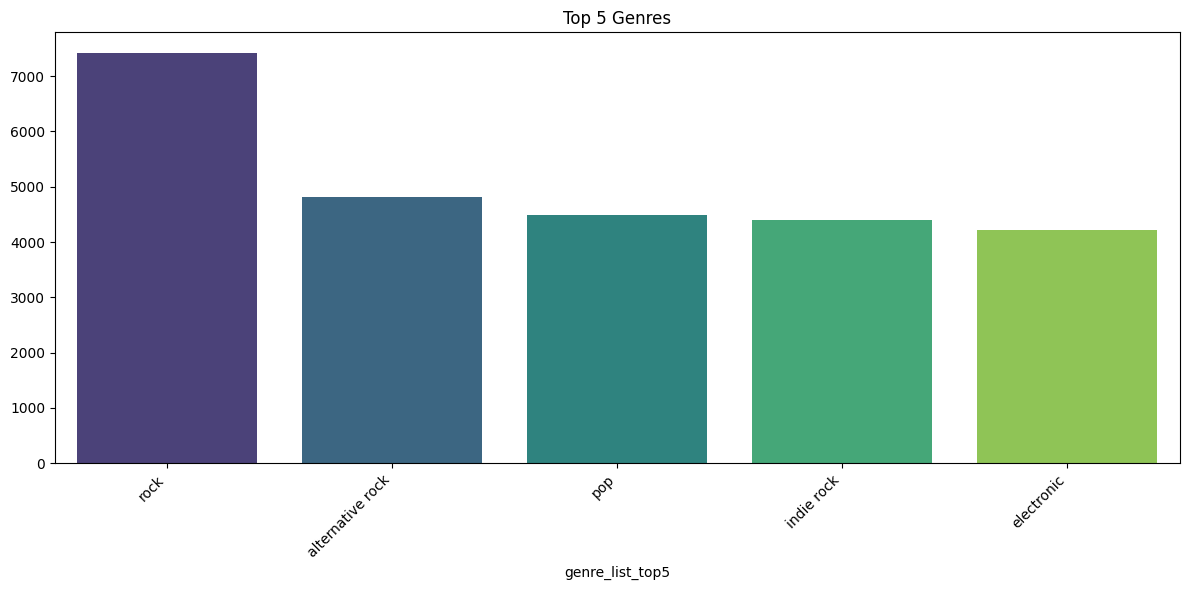

In [67]:
import ast

# 1. Convert string-lists to actual lists
df_features["genre_list_top5"] = df_features["genre_list_top5"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# 2. Now explode and count
top_counts = df_features["genre_list_top5"].explode().value_counts()

# 3. Plotting only the Top 20 (otherwise it's too crowded to read!)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_counts.head(5).index,
    y=top_counts.head(5).values,
    palette="viridis"
)

plt.title("Top 5 Genres")
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Prevents label cutoff
plt.show()

## Which is the most populated genre?
Most songs in this dataset fall under the Rock umbrella. This aligns with historical trends, Rock has enjoyed a dominant 'back-catalog' advantage since the 1950s. While Pop has been a major competitor for decades and Electronic music is currently seeing a production surge, they lack the sheer volume of 70+ years of Rock recordings. Furthermore, if we grouped Alternative and Indie Rock into the primary Rock category, the genre's lead would be even more staggering, representing a vast majority of the available musical history in this collection

## Lyrics Length Analysis

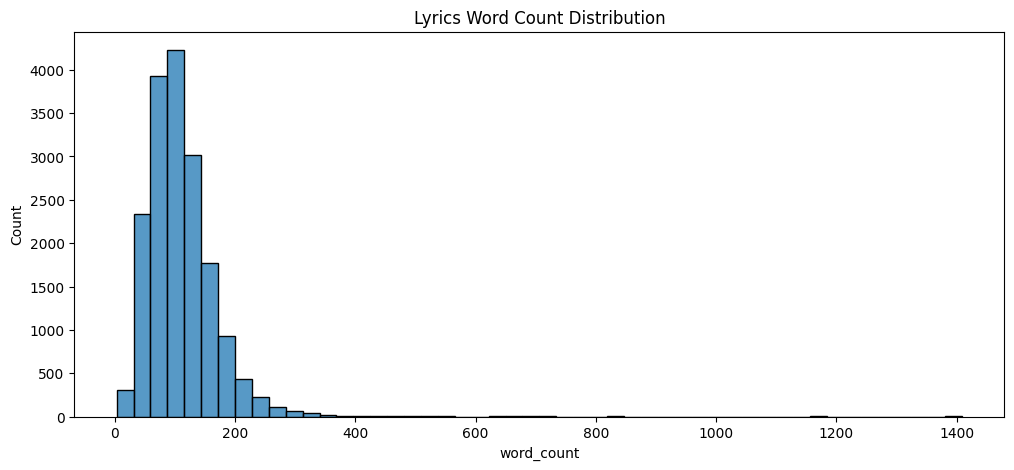

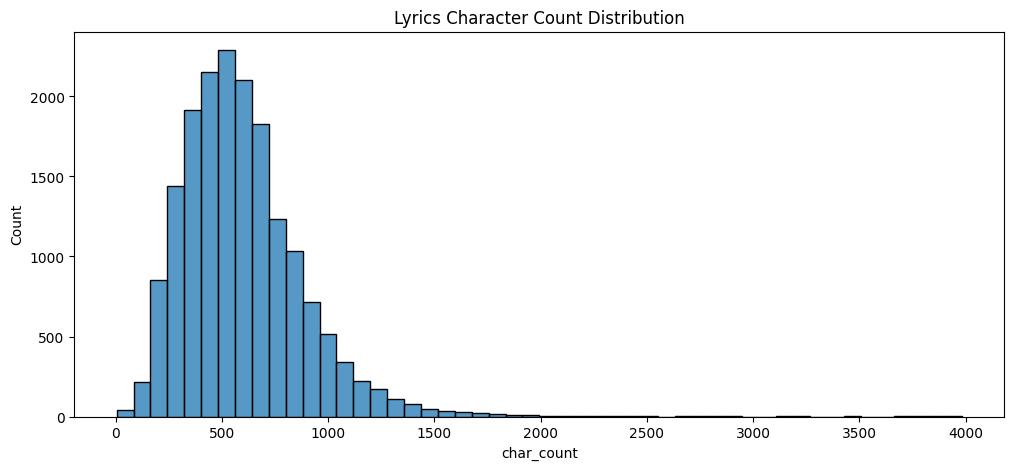

In [68]:
df_features["word_count"] = df_features["lyrics"].apply(lambda x: len(str(x).split()))
df_features["char_count"] = df_features["lyrics"].apply(lambda x: len(str(x)))

plt.figure(figsize=(12,5))
sns.histplot(df_features["word_count"], bins=50)
plt.title("Lyrics Word Count Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df_features["char_count"], bins=50)
plt.title("Lyrics Character Count Distribution")
plt.show()

## What the lyrics length tells us
As we can see most songs are have around 150-200 words and 500-1000 characters. This aligns with the average length of the song being 3-4 minutes, regardless of genre and it being easily digestible. Also our genres focus primarily on the sound and the isntrumental rather than in the lyrics(especially in the POP genre where lyrics often consist meaningles "catchy" choruses). One clear outlier would be Hip-Hop/Rap, which gives much more meaning in the words said in the rap and very little attention to the sound which is very often a 10-second sound looped to 3-4 minutes. Near the 0 words it is very likely electronic music, where lyrics are very often in the background complimenting the sound, but not adding anything substantial to the song. Ultimately, this data confirms a high degree of uniformity in lyrical length across diverse genres, suggesting that regardless of the musical style, artists tend to limit word counts to ensure the song remains accessible and engaging for the average listener.

## Sentiment Analysis by Genre (VADER)
We use VADER to analyze the sentiment of the lyrics and the plot the results. Our initial guess would be that pop songs will generally be happier while rock songs will be sadder/angrier.

In [69]:
analyzer = SentimentIntensityAnalyzer()

def categorize_vader(text):
    # Handle potential empty lyrics or non-string data
    if not isinstance(text, str) or text.strip() == "":
        return "Neutral"

    # Get the compound score (-1 to 1)
    score = analyzer.polarity_scores(text)['compound']

    # Standard VADER thresholds
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'


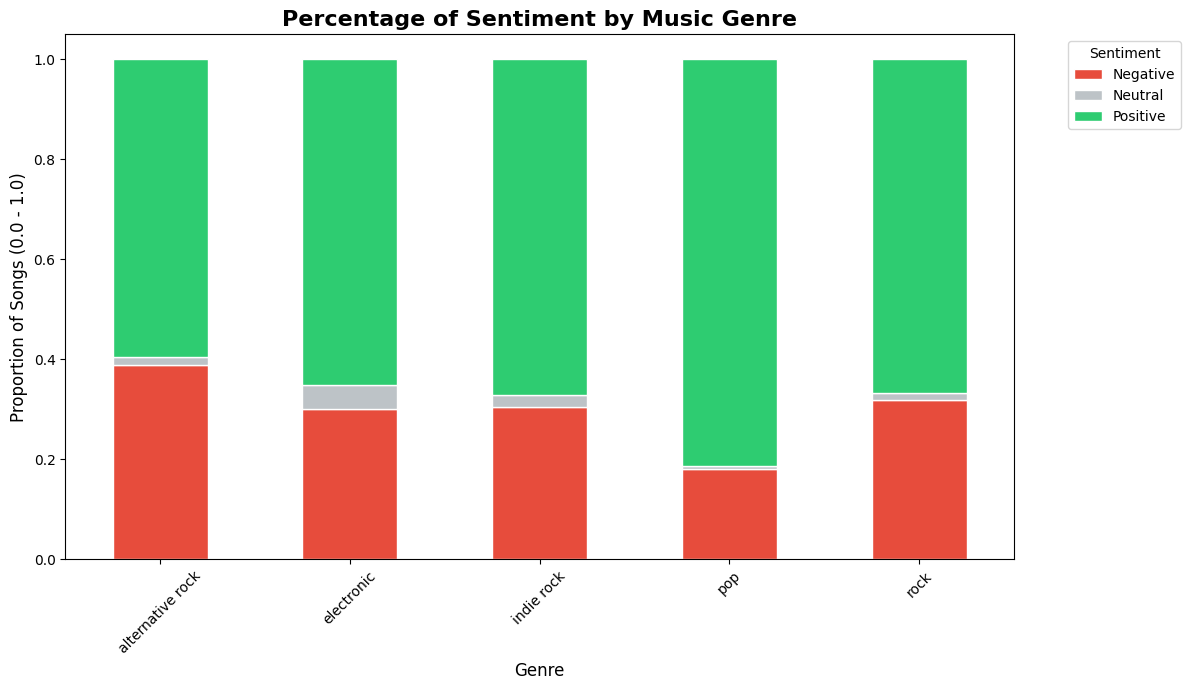

In [70]:
# Defensive copy
df = df_multimodal.copy()
df['sentiment_label'] = df['lyrics'].apply(categorize_vader)
sentiment_table = pd.crosstab(df['genre'], df['sentiment_label'])

sentiment_pct = sentiment_table.div(sentiment_table.sum(axis=1), axis=0)

# 2. Plotting
# Using a color palette that makes sense: Red=Negative, Gray=Neutral, Green=Positive
ax = sentiment_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    color=['#e74c3c', '#bdc3c7', '#2ecc71'],
    edgecolor='white'
)

# 3. Add labels and titles for your report
plt.title('Percentage of Sentiment by Music Genre', fontsize=16, fontweight='bold')
plt.ylabel('Proportion of Songs (0.0 - 1.0)', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=45)

# Move the legend outside so it doesn't cover the bars
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## Are pop songs happier and rock sadder?

### Confirmed hypothesis
Our initial hypothesis turns out to be correct as Pop music has the highest number of positive sentiment, roughly 80% of songs, significantly higher than Rock songs.

### Alternative Rock sadness
Alternative Rock exhibited the most amount of negative sentiment songs, with nearly 40% of total songs having a negative sentiment. This aligns with out belief that this genre of music is generally "darker" and has a more angry and troubled theme in its lyrics

### Electronic Neutrality
Interestingly, Electronic music displays a higher ratio of neutral sentiment songs compared to Pop. This could be attributed to the nature of the genre, which often features more repetitive lyrics or instrumental-heavy segments that lack highly polarized emotional keywords.

### General findings
Interestingly, most songs have a positive sentiment. In my opinion this shows the limitation of this tool in understanding context. Since this is a rule-based classification model with a lexicon it doesn't really understand context, so a sentence like "I hate that I love you" might be clasified as positive, since love is considered positive and generally appears quite often according to the wordcloud, when in reality it isn't a positive sentence. This I think highlights the limitation of this tool.

In [71]:
def produce_similarity_table(embeddings_df, features_df, sample_id):
    target_vector = embeddings_df.loc[[sample_id]].to_numpy()
    all_vectors = embeddings_df.to_numpy()

    sim_scores = cosine_similarity(target_vector, all_vectors).flatten()

    scores_series = pd.Series(sim_scores, index=embeddings_df.index, name='similarity_score')

    recommendations = scores_series.sort_values(ascending=False).drop(index=sample_id)

    final_results = pd.DataFrame(recommendations).join(features_df[['genre_list_all']])

    return final_results

In [72]:
sample_id = 'KA4HKcPzVAxBeE4t'
display_songs = 5
if df_features.index.name != 'id':
    df_features = df_features.set_index('id')

## Similarity Search based on lyrics

In [73]:
# Get results
final_results = produce_similarity_table(df_lyrics, df_features, sample_id)

# Get target song info for the print statement
target_genre = df_features.loc[sample_id, 'genre_list_all']

print(f"Similarities for song {sample_id} with genres {target_genre}:")
display(final_results.head(display_songs))

Similarities for song KA4HKcPzVAxBeE4t with genres ['post hardcore', 'punk', 'alternative rock']:


,similarity_score,genre_list_all
id,,
k1Nap3pGm1zeOQSK,0.715190,"['indie rock', 'indie pop']"
ZNIR5kphBjcTZtN9,0.713685,"['indie rock', 'folk', 'singer songwriter']"
jGFhMzRRxhJOx5gR,0.698746,"['indie rock', 'rock']"
2quHrGgiN02VxbtM,0.694383,"['indie rock', 'rock', 'indie rock']"
k1Vs3NiBhseBVgl3,0.693877,['indie rock']



## Similarity Search based on audio


In [74]:
# Get results
final_results = produce_similarity_table(df_audio, df_features, sample_id)

# Get target song info for the print statement
target_genre = df_features.loc[sample_id, 'genre_list_all']

print(f"Similarities for song {sample_id} with genres {target_genre}:")
display(final_results.head(display_songs))

Similarities for song KA4HKcPzVAxBeE4t with genres ['post hardcore', 'punk', 'alternative rock']:


,similarity_score,genre_list_all
id,,
xV29YakmRPsM4JcJ,0.713480,"['rock', 'alternative rock', 'grunge']"
LTk1WePlm1fipQLt,0.685868,"['alternative rock', 'emocore', 'metalcore', '..."
0tKSRIcj9gn6IJ5X,0.675155,"['post hardcore', 'rock', 'post hardcore', 'el..."
Cvi6rWulL3m2kilD,0.662136,"['post grunge', 'rock', 'alternative rock', 'g..."
Dt16hqCF1EJFH078,0.658443,"['screamo', 'alternative rock', 'post hardcore..."


## Similarity Search based on lyrics with word2vec embeding



In [ ]:
df_lyrics = pd.read_csv("/content/text_embeddings_word2vec.csv", index_col=0)
# Get results
final_results = produce_similarity_table(df_lyrics, df_features, sample_id)

# Get target song info for the print statement
target_genre = df_features.loc[sample_id, 'genre_list_all']

print(f"Similarities for song {sample_id} with genres {target_genre}:")
display(final_results.head(display_songs))

Similarities for song KA4HKcPzVAxBeE4t with genres ['post hardcore', 'punk', 'alternative rock']:


,similarity_score,genre_list_all
id,,
6VuMWIkaWRmG6mUw,0.909307,"['new rave', 'indie rock', 'electronica', 'new..."
eIYVY3ueljl97lH7,0.904592,"['folk', 'singer songwriter', 'folk rock', 'ro..."
d72RW8vlRVU85sF5,0.903682,['indie rock']
T4ONeiY76yzxAJu6,0.902701,"['alternative rock', 'rock', 'garage rock', 'a..."
qVuVgfpXIyXe6L3N,0.901029,"['indie pop', 'indie rock', 'pop rock']"


## Results
To rank the results we used the genres of the sample song and the top-5 recomended ones, as we believe that the best way to rank them was to know what other listeners clasify them as.
### The clear winner
Comparing the 3 resulting top-5 similar songs we observe that the PCA audio embeding is a clear winner, as it finds all 5 top songs to be of quite similar genre, with most being alternative rock (or rock in general) and similar to post hardcore and punk.

### The runner up
SBERT is clearly superior than word2vec embedings since it does find songs of similar genres, but it does have some misses as the top 2 songs are apparently techno and electronic the first one and folk the second one, which is not really close to punk and alt rock

### Confidently wrong
The word2vec embeding similarity scores show the clear limitations of this type of embeding, since it matches a lo-fi, indie rock song to our sample with a near 90% similarity which makes no sense. In general except from that one outlier it does seem to have some acceptable similar songs, but the fact it finds them all at a 90% similarity score is really hard to believe. Word2Vec treats the song as a 'bag of words,' losing the semantic structure that SBERT maintains. This leads to high similarity scores based on shared vocabulary (e.g., common rock tropes) while completely missing the stylistic execution of the track.

### The verdict
While we would expect the SBERT lyrics embedings to dominate this, the fact is that our dataset is more suited to sound analysis, since a song's genre is defined by its sound and not necesarily its lyrics.
### The "Hurt" case study
One example I can find is the song "Hurt" originally by Nine Inch Nails and later covered by Johnny Cash. While both interpretations have the same lyrics, that is where the similarities end, with the songs being clasified in different genres, and the same lyrics even taking a different meaning in the listener's mind, where the Nine Inch Nails interpetation shows a man that is battling addiction and himself, the overall feel of Cash's cover is of a man in his later years regretting his past choices in life. The same song, just by the sound and the person singing it can be entirely different.

| Metric | Nine Inch Nails (Original) | Johnny Cash (Cover) | Similarity Logic |
| :--- | :--- | :--- | :--- |
| **Lyrics (SBERT)** | 99% Similarity | 99% Similarity | Identical "Script" |
| **Audio (PCA)** | Industrial / Aggressive | Acoustic / Sparse | **Low Similarity** |
| **Interpretation** | Battle with addiction | Regret and mortality | Different Context |


# Part B: Categorization, Fusion and Evaluation

### Additional Imports

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Classification Models (Unimodal)

In this section, we train two different classifiers for genre classification:

- **Logistic Regression**
- **Random Forest**

Each classifier is trained separately on:

- **Text-only embeddings**: Sentence-BERT text embeddings.
- **Audio-only features**: raw MFCC statistics, which are transformed into PCA audio embeddings inside each cross-validation fold.

Although PCA audio embeddings were created in Part A for exploratory analysis and similarity search, the formal 10-fold evaluation in Part B applies Imputation, Standardization and PCA only on the training portion of each fold. This avoids possible unsupervised data leakage from the test fold.

This gives separate unimodal baselines and allows us to compare both the input modality and the classification algorithm.

### Load and Align Embeddings

In [ ]:
# Load saved embeddings from Part A
text_embeddings_df = pd.read_csv("/content/text_embeddings_sbert.csv", index_col=0)
audio_embeddings_df = pd.read_csv("/content/audio_embeddings_pca.csv", index_col=0)

# Make sure IDs are strings
text_embeddings_df.index = text_embeddings_df.index.astype(str)
audio_embeddings_df.index = audio_embeddings_df.index.astype(str)

# Make sure df_features uses id as index
if "id" in df_features.columns:
    labels_df = df_features.set_index("id").copy()
else:
    labels_df = df_features.copy()

labels_df.index = labels_df.index.astype(str)

# Keep only songs that exist in all three sources
common_ids = (
    text_embeddings_df.index
    .intersection(audio_embeddings_df.index)
    .intersection(labels_df.index)
)

text_embeddings_df = text_embeddings_df.loc[common_ids].copy()
audio_embeddings_df = audio_embeddings_df.loc[common_ids].copy()
labels_df = labels_df.loc[common_ids].copy()

print("Text embeddings shape:", text_embeddings_df.shape)
print("Audio embeddings shape:", audio_embeddings_df.shape)
print("Labels shape:", labels_df.shape)
print("Genres:", labels_df["genre"].unique())

Text embeddings shape: (17449, 384)
Audio embeddings shape: (17449, 80)
Labels shape: (17449, 8)
Genres: <StringArray>
['alternative rock', 'electronic', 'indie rock', 'pop', 'rock']
Length: 5, dtype: str


### Prepare X (audio and text) and y

In [14]:
# Text input: pre-computed SBERT embeddings
X_text = text_embeddings_df.values.astype(np.float32)

# Audio input for Part B formal evaluation:
# Use RAW MFCC statistics, not the pre-computed PCA audio embeddings.
# PCA will be fitted inside each CV fold to avoid unsupervised leakage.
labels_df["mfcc_stats"] = labels_df["mfcc_stats"].apply(ensure_list)
X_audio_raw = np.array(labels_df["mfcc_stats"].tolist(), dtype=np.float32)

# Keep the old Part A PCA audio embeddings only for reference / EDA / similarity analysis.
X_audio_pca_partA = audio_embeddings_df.values.astype(np.float32)

y_labels = labels_df["genre"].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

print("X_text shape:", X_text.shape)
print("X_audio_raw shape:", X_audio_raw.shape)
print("Part A PCA audio embeddings shape:", X_audio_pca_partA.shape)
print("y shape:", y.shape)
print("Encoded classes:", list(label_encoder.classes_))

X_text shape: (17449, 384)
X_audio_raw shape: (17449, 104)
Part A PCA audio embeddings shape: (17449, 80)
y shape: (17449,)
Encoded classes: ['alternative rock', 'electronic', 'indie rock', 'pop', 'rock']


### Preliminary train/test split

A stratified train/test split is used here to obtain initial baseline results for the unimodal and fusion models.

The formal evaluation required by the assignment is performed later using 10-fold cross-validation.

In [15]:
X_text_train, X_text_test, X_audio_train, X_audio_test, y_train, y_test = train_test_split(
    X_text,
    X_audio_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Text train:", X_text_train.shape)
print("Text test:", X_text_test.shape)
print("Raw audio train:", X_audio_train.shape)
print("Raw audio test:", X_audio_test.shape)

Text train: (13959, 384)
Text test: (3490, 384)
Raw audio train: (13959, 104)
Raw audio test: (3490, 104)


### Define the classifiers

We use two different classifiers:

1. **Logistic Regression**, which is efficient for dense embedding vectors and supports class probability estimates.
2. **Random Forest**, which is a non-linear ensemble method and provides a different modelling approach.

Logistic Regression is used instead of SVM because Part B requires repeated training during 10-fold cross-validation for all unimodal and fusion experiments. This makes runtime much more manageable while still using a valid supervised classifier.

Both classifiers provide `predict_proba`, which is required for Late Fusion.

For Logistic Regression, scaling is applied because linear models are sensitive to feature scale.

For Random Forest, scaling is not required.

In [16]:
classifiers = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

### Train unimodal models

Each classifier is trained twice:

- once using only the text embeddings
- once using only the audio embeddings

This produces four unimodal baseline models in total.

In [17]:
unimodal_results = []
trained_models = {}

def make_audio_pipeline(base_clf):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("clf", clone(base_clf))
    ])

for clf_name, clf in classifiers.items():
    for modality_name, X_train, X_test in [
        ("Text-only", X_text_train, X_text_test),
        ("Audio-only", X_audio_train, X_audio_test)
    ]:
        model_key = f"{clf_name} ({modality_name})"

        if modality_name == "Audio-only":
            model = make_audio_pipeline(clf)
        else:
            model = clone(clf)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        trained_models[model_key] = model

        unimodal_results.append({
            "model": model_key,
            "classifier": clf_name,
            "modality": modality_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        })

        print("=" * 80)
        print(model_key)
        print("=" * 80)
        print(classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        ))

Logistic Regression (Text-only)
                  precision    recall  f1-score   support

alternative rock       0.33      0.35      0.34       698
      electronic       0.36      0.31      0.33       698
      indie rock       0.37      0.35      0.36       698
             pop       0.44      0.55      0.49       698
            rock       0.30      0.27      0.28       698

        accuracy                           0.36      3490
       macro avg       0.36      0.36      0.36      3490
    weighted avg       0.36      0.36      0.36      3490

Logistic Regression (Audio-only)
                  precision    recall  f1-score   support

alternative rock       0.41      0.49      0.44       698
      electronic       0.48      0.49      0.49       698
      indie rock       0.40      0.37      0.39       698
             pop       0.58      0.57      0.57       698
            rock       0.39      0.34      0.36       698

        accuracy                           0.45      3490
  

In [18]:
unimodal_results_df = pd.DataFrame(unimodal_results)
display(unimodal_results_df.sort_values("f1_macro", ascending=False))

,model,classifier,modality,accuracy,precision_macro,recall_macro,f1_macro
1,Logistic Regression (Audio-only),Logistic Regression,Audio-only,0.451576,0.451017,0.451576,0.450189
3,Random Forest (Audio-only),Random Forest,Audio-only,0.428367,0.422271,0.428367,0.422391
0,Logistic Regression (Text-only),Logistic Regression,Text-only,0.364756,0.359868,0.364756,0.360365
2,Random Forest (Text-only),Random Forest,Text-only,0.348424,0.340383,0.348424,0.339787


### Initial unimodal comparison

The results above compare two dimensions:

1. **Modality comparison**: whether text embeddings or audio embeddings perform better.
2. **Classifier comparison**: whether Logistic Regression or Random Forest is more suitable for the available embeddings.

These unimodal results serve as baseline models for the next stages of Part B.

# 2. Multimodal Fusion

In this section, we combine the two modalities:

- Text embeddings
- Audio embeddings

Two fusion strategies are implemented:

1. **Early Fusion**: concatenate text and audio vectors before training.
2. **Late Fusion**: combine the prediction probabilities of the already trained text-only and audio-only models.

## 2.1 Early Fusion

For early fusion, the text and audio embedding vectors are concatenated into a single feature vector.

This fused representation is then used to train a classifier, called **Model C (Fused)**.

In [19]:
# For the preliminary train/test split only:
# fit audio preprocessing on the training set and transform the test set.
audio_preprocess_prelim = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42))
])

X_audio_train_pca = audio_preprocess_prelim.fit_transform(X_audio_train)
X_audio_test_pca = audio_preprocess_prelim.transform(X_audio_test)

X_fused_train = np.hstack([X_text_train, X_audio_train_pca])
X_fused_test = np.hstack([X_text_test, X_audio_test_pca])

print("Text train shape:", X_text_train.shape)
print("Audio train PCA shape:", X_audio_train_pca.shape)
print("Fused train shape:", X_fused_train.shape)

print("Text test shape:", X_text_test.shape)
print("Audio test PCA shape:", X_audio_test_pca.shape)
print("Fused test shape:", X_fused_test.shape)

Text train shape: (13959, 384)
Audio train PCA shape: (13959, 80)
Fused train shape: (13959, 464)
Text test shape: (3490, 384)
Audio test PCA shape: (3490, 80)
Fused test shape: (3490, 464)


In [20]:
early_fusion_results = []
early_fusion_models = {}

for clf_name, clf in classifiers.items():
    model_key = f"{clf_name} (Early Fusion)"

    model = clone(clf)
    model.fit(X_fused_train, y_train)

    y_pred_fused = model.predict(X_fused_test)

    early_fusion_models[model_key] = model

    early_fusion_results.append({
        "model": model_key,
        "classifier": clf_name,
        "fusion_type": "Early Fusion",
        "accuracy": accuracy_score(y_test, y_pred_fused),
        "precision_macro": precision_score(y_test, y_pred_fused, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred_fused, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred_fused, average="macro", zero_division=0),
    })

    print("=" * 80)
    print(model_key)
    print("=" * 80)
    print(classification_report(
        y_test,
        y_pred_fused,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

Logistic Regression (Early Fusion)
                  precision    recall  f1-score   support

alternative rock       0.41      0.45      0.43       698
      electronic       0.52      0.50      0.51       698
      indie rock       0.41      0.37      0.39       698
             pop       0.57      0.62      0.59       698
            rock       0.39      0.36      0.37       698

        accuracy                           0.46      3490
       macro avg       0.46      0.46      0.46      3490
    weighted avg       0.46      0.46      0.46      3490

Random Forest (Early Fusion)
                  precision    recall  f1-score   support

alternative rock       0.37      0.43      0.40       698
      electronic       0.45      0.49      0.47       698
      indie rock       0.38      0.33      0.35       698
             pop       0.52      0.64      0.57       698
            rock       0.34      0.22      0.27       698

        accuracy                           0.42      3490
   

In [21]:
early_fusion_results_df = pd.DataFrame(early_fusion_results)
display(early_fusion_results_df.sort_values("f1_macro", ascending=False))

,model,classifier,fusion_type,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression (Early Fusion),Logistic Regression,Early Fusion,0.460458,0.458090,0.460458,0.458684
1,Random Forest (Early Fusion),Random Forest,Early Fusion,0.423209,0.413058,0.423209,0.413322


## 2.2 Late Fusion

For late fusion, the text-only and audio-only models are not merged at the feature level.

Instead, each model produces class probabilities:

- Text-only model probabilities
- Audio-only model probabilities

The final prediction is obtained by averaging these probabilities and selecting the class with the highest average probability.

In [22]:
late_fusion_results = {}
late_fusion_predictions = {}

for clf_name in classifiers.keys():
    text_model_key = f"{clf_name} (Text-only)"
    audio_model_key = f"{clf_name} (Audio-only)"

    text_model = trained_models[text_model_key]
    audio_model = trained_models[audio_model_key]

    text_probs = text_model.predict_proba(X_text_test)
    audio_probs = audio_model.predict_proba(X_audio_test)

    avg_probs = (text_probs + audio_probs) / 2
    y_pred_late = np.argmax(avg_probs, axis=1)

    late_fusion_predictions[f"{clf_name} (Late Fusion)"] = y_pred_late

    late_fusion_results[f"{clf_name} (Late Fusion)"] = {
        "model": f"{clf_name} (Late Fusion)",
        "classifier": clf_name,
        "fusion_type": "Late Fusion",
        "accuracy": accuracy_score(y_test, y_pred_late),
        "precision_macro": precision_score(y_test, y_pred_late, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred_late, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred_late, average="macro", zero_division=0),
    }

    print("=" * 80)
    print(f"{clf_name} (Late Fusion)")
    print("=" * 80)
    print(classification_report(
        y_test,
        y_pred_late,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

Logistic Regression (Late Fusion)
                  precision    recall  f1-score   support

alternative rock       0.42      0.45      0.43       698
      electronic       0.51      0.49      0.50       698
      indie rock       0.43      0.39      0.41       698
             pop       0.55      0.67      0.61       698
            rock       0.38      0.33      0.35       698

        accuracy                           0.46      3490
       macro avg       0.46      0.46      0.46      3490
    weighted avg       0.46      0.46      0.46      3490

Random Forest (Late Fusion)
                  precision    recall  f1-score   support

alternative rock       0.40      0.42      0.41       698
      electronic       0.50      0.51      0.50       698
      indie rock       0.39      0.35      0.37       698
             pop       0.52      0.67      0.59       698
            rock       0.37      0.28      0.32       698

        accuracy                           0.45      3490
     

In [23]:
late_fusion_results_df = pd.DataFrame(late_fusion_results.values())
display(late_fusion_results_df.sort_values("f1_macro", ascending=False))

,model,classifier,fusion_type,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression (Late Fusion),Logistic Regression,Late Fusion,0.464470,0.458802,0.464470,0.459710
1,Random Forest (Late Fusion),Random Forest,Late Fusion,0.446705,0.438131,0.446705,0.439004


## Fusion Summary

This section produced:

- Early-fusion models, trained directly on concatenated text and audio embeddings.
- Late-fusion predictions, produced by averaging the class probabilities of the text-only and audio-only models.

The detailed comparison with unimodal models, cross-validation, confusion matrices, and final F1-score bar chart will be performed in the evaluation section.

# 3. Experimental Procedure and Evaluation

In this section, all previous classification experiments are evaluated using **10-fold cross-validation**.

The evaluated approaches are:

- **Model A: Text-only**
- **Model B: Audio-only**
- **Model C: Early Fusion**
- **Late Fusion**

For each approach, both classifiers from the previous sections are evaluated:

- Logistic Regression
- Random Forest

For every experiment, we report:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score

Confusion matrices are created for the three main approaches:

- Model A: Text-only
- Model B: Audio-only
- Model C: Early Fusion

## 3.1 - 3.2 Cross-Validation and Metrics

### 10-fold CV Definition

In [5]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

### Full Fused Matrix

In [24]:
print("Text features:", X_text.shape)
print("Raw audio features:", X_audio_raw.shape)
print("Labels:", y.shape)

print(
    "For leakage-safe 10-fold CV, audio PCA is fitted inside each fold, "
    "so the final fused dimensionality is computed separately per fold."
)

Text features: (17449, 384)
Raw audio features: (17449, 104)
Labels: (17449,)
For leakage-safe 10-fold CV, audio PCA is fitted inside each fold, so the final fused dimensionality is computed separately per fold.


### Cross-validation helper function

The following function manually performs 10-fold cross-validation.

Manual implementation is used because late fusion requires training separate text-only and audio-only models inside each fold and then combining their probability outputs.

In [25]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

### 10-fold cross-validation for all experiments

For each classifier, four experiments are evaluated:

1. Text-only classification
2. Audio-only classification
3. Early Fusion
4. Late Fusion

Late Fusion is implemented by averaging the class probabilities of the text-only and audio-only models in each fold.

In [26]:
# 10-fold CV Evaluation with leakage-safe audio PCA

import seaborn as sns

def preprocess_audio_fold(X_audio_train, X_audio_test):
    """
    Fit audio preprocessing only on the training fold.
    Then transform both train and test fold.
    This avoids PCA/scaling leakage from the test fold.
    """
    audio_preprocess = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42))
    ])

    X_audio_train_pca = audio_preprocess.fit_transform(X_audio_train)
    X_audio_test_pca = audio_preprocess.transform(X_audio_test)

    return X_audio_train_pca, X_audio_test_pca


def evaluate_text_cv(model, X_text, y, cv, model_name):
    fold_rows = []
    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y), start=1):
        clf = clone(model)

        clf.fit(X_text[train_idx], y[train_idx])
        y_pred = clf.predict(X_text[test_idx])

        metrics = compute_metrics(y[test_idx], y_pred)
        metrics.update({
            "fold": fold,
            "model": model_name,
            "approach": "Text-only"
        })

        fold_rows.append(metrics)
        y_true_all.extend(y[test_idx])
        y_pred_all.extend(y_pred)

    return pd.DataFrame(fold_rows), np.array(y_true_all), np.array(y_pred_all)


def evaluate_audio_cv(model, X_audio_raw, y, cv, model_name):
    fold_rows = []
    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_audio_raw, y), start=1):
        clf = clone(model)

        X_audio_train_pca, X_audio_test_pca = preprocess_audio_fold(
            X_audio_raw[train_idx],
            X_audio_raw[test_idx]
        )

        clf.fit(X_audio_train_pca, y[train_idx])
        y_pred = clf.predict(X_audio_test_pca)

        metrics = compute_metrics(y[test_idx], y_pred)
        metrics.update({
            "fold": fold,
            "model": model_name,
            "approach": "Audio-only"
        })

        fold_rows.append(metrics)
        y_true_all.extend(y[test_idx])
        y_pred_all.extend(y_pred)

    return pd.DataFrame(fold_rows), np.array(y_true_all), np.array(y_pred_all)


def evaluate_early_fusion_cv(model, X_text, X_audio_raw, y, cv, model_name):
    fold_rows = []
    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y), start=1):
        clf = clone(model)

        X_audio_train_pca, X_audio_test_pca = preprocess_audio_fold(
            X_audio_raw[train_idx],
            X_audio_raw[test_idx]
        )

        X_fused_train = np.hstack([X_text[train_idx], X_audio_train_pca])
        X_fused_test = np.hstack([X_text[test_idx], X_audio_test_pca])

        clf.fit(X_fused_train, y[train_idx])
        y_pred = clf.predict(X_fused_test)

        metrics = compute_metrics(y[test_idx], y_pred)
        metrics.update({
            "fold": fold,
            "model": model_name,
            "approach": "Early Fusion"
        })

        fold_rows.append(metrics)
        y_true_all.extend(y[test_idx])
        y_pred_all.extend(y_pred)

    return pd.DataFrame(fold_rows), np.array(y_true_all), np.array(y_pred_all)


def evaluate_late_fusion_cv(base_model, X_text, X_audio_raw, y, cv, model_name):
    fold_rows = []
    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y), start=1):
        text_model = clone(base_model)
        audio_model = clone(base_model)

        X_audio_train_pca, X_audio_test_pca = preprocess_audio_fold(
            X_audio_raw[train_idx],
            X_audio_raw[test_idx]
        )

        text_model.fit(X_text[train_idx], y[train_idx])
        audio_model.fit(X_audio_train_pca, y[train_idx])

        text_probs = text_model.predict_proba(X_text[test_idx])
        audio_probs = audio_model.predict_proba(X_audio_test_pca)

        avg_probs = (text_probs + audio_probs) / 2
        y_pred = np.argmax(avg_probs, axis=1)

        metrics = compute_metrics(y[test_idx], y_pred)
        metrics.update({
            "fold": fold,
            "model": model_name,
            "approach": "Late Fusion"
        })

        fold_rows.append(metrics)
        y_true_all.extend(y[test_idx])
        y_pred_all.extend(y_pred)

    return pd.DataFrame(fold_rows), np.array(y_true_all), np.array(y_pred_all)

In [27]:
# Run leakage-safe 10-fold CV for all approaches

all_cv_results = []
cv_predictions = {}

for clf_name, clf in classifiers.items():

    # Text-only
    model_name = f"{clf_name} (Text-only)"
    results_df, y_true_cv, y_pred_cv = evaluate_text_cv(
        model=clf,
        X_text=X_text,
        y=y,
        cv=cv,
        model_name=model_name
    )
    all_cv_results.append(results_df)
    cv_predictions[model_name] = {
        "y_true": y_true_cv,
        "y_pred": y_pred_cv
    }

    # Audio-only
    model_name = f"{clf_name} (Audio-only)"
    results_df, y_true_cv, y_pred_cv = evaluate_audio_cv(
        model=clf,
        X_audio_raw=X_audio_raw,
        y=y,
        cv=cv,
        model_name=model_name
    )
    all_cv_results.append(results_df)
    cv_predictions[model_name] = {
        "y_true": y_true_cv,
        "y_pred": y_pred_cv
    }

    # Early Fusion
    model_name = f"{clf_name} (Early Fusion)"
    results_df, y_true_cv, y_pred_cv = evaluate_early_fusion_cv(
        model=clf,
        X_text=X_text,
        X_audio_raw=X_audio_raw,
        y=y,
        cv=cv,
        model_name=model_name
    )
    all_cv_results.append(results_df)
    cv_predictions[model_name] = {
        "y_true": y_true_cv,
        "y_pred": y_pred_cv
    }

    # Late Fusion
    model_name = f"{clf_name} (Late Fusion)"
    results_df, y_true_cv, y_pred_cv = evaluate_late_fusion_cv(
        base_model=clf,
        X_text=X_text,
        X_audio_raw=X_audio_raw,
        y=y,
        cv=cv,
        model_name=model_name
    )
    all_cv_results.append(results_df)
    cv_predictions[model_name] = {
        "y_true": y_true_cv,
        "y_pred": y_pred_cv
    }


cv_results_df = pd.concat(all_cv_results, ignore_index=True)

display(cv_results_df.head())

,accuracy,precision_macro,recall_macro,f1_macro,fold,model,approach
0,0.355301,0.347865,0.355301,0.349417,1,Logistic Regression (Text-only),Text-only
1,0.370201,0.363336,0.370201,0.363830,2,Logistic Regression (Text-only),Text-only
2,0.375931,0.370021,0.375931,0.370212,3,Logistic Regression (Text-only),Text-only
3,0.361032,0.357438,0.361032,0.357793,4,Logistic Regression (Text-only),Text-only
4,0.356447,0.350274,0.356447,0.351511,5,Logistic Regression (Text-only),Text-only


In [28]:
cv_summary_df = (
    cv_results_df
    .groupby(["model", "approach"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_macro_mean=("precision_macro", "mean"),
        precision_macro_std=("precision_macro", "std"),
        recall_macro_mean=("recall_macro", "mean"),
        recall_macro_std=("recall_macro", "std"),
        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_std=("f1_macro", "std"),
    )
    .reset_index()
    .sort_values("f1_macro_mean", ascending=False)
)

display(cv_summary_df)

,model,approach,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
1,Logistic Regression (Early Fusion),Early Fusion,0.467822,0.010721,0.465670,0.011169,0.467824,0.010726,0.466097,0.010813
2,Logistic Regression (Late Fusion),Late Fusion,0.465586,0.012737,0.460225,0.014089,0.465589,0.012740,0.460464,0.013397
6,Random Forest (Late Fusion),Late Fusion,0.459913,0.013912,0.451739,0.015227,0.459915,0.013915,0.452446,0.014315
0,Logistic Regression (Audio-only),Audio-only,0.449138,0.009469,0.448787,0.009457,0.449141,0.009473,0.447638,0.009378
4,Random Forest (Audio-only),Audio-only,0.430455,0.008942,0.424298,0.008425,0.430462,0.008948,0.424629,0.008390
5,Random Forest (Early Fusion),Early Fusion,0.425756,0.015743,0.416535,0.016786,0.425759,0.015747,0.417091,0.016323
3,Logistic Regression (Text-only),Text-only,0.361741,0.012059,0.355785,0.012401,0.361738,0.012056,0.356442,0.012119
7,Random Forest (Text-only),Text-only,0.339160,0.010668,0.331939,0.010839,0.339158,0.010669,0.331548,0.010461


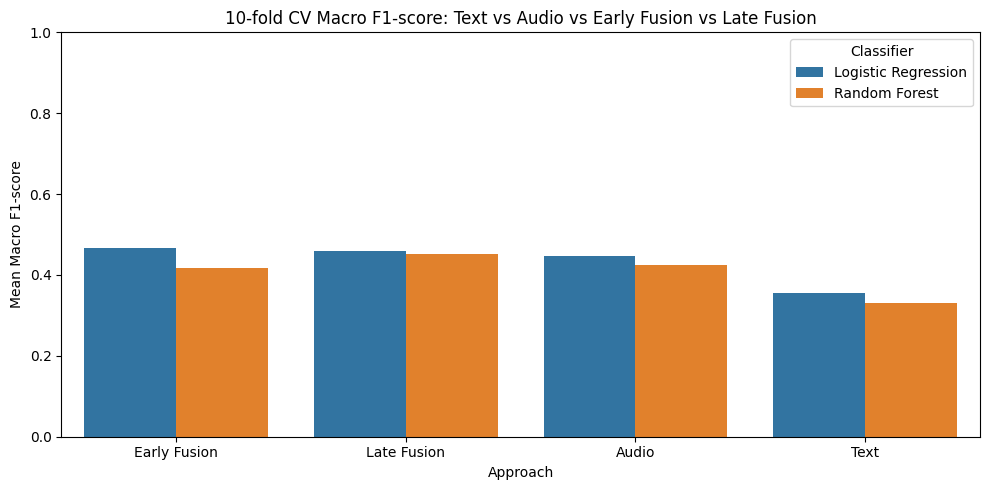

,classifier,approach_label,f1_macro_mean,f1_macro_std
1,Logistic Regression,Early Fusion,0.466097,0.010813
2,Logistic Regression,Late Fusion,0.460464,0.013397
6,Random Forest,Late Fusion,0.452446,0.014315
0,Logistic Regression,Audio,0.447638,0.009378
4,Random Forest,Audio,0.424629,0.008390
5,Random Forest,Early Fusion,0.417091,0.016323
3,Logistic Regression,Text,0.356442,0.012119
7,Random Forest,Text,0.331548,0.010461


In [29]:
plot_df = cv_summary_df[
    cv_summary_df["approach"].isin(["Text-only", "Audio-only", "Early Fusion", "Late Fusion"])
].copy()

plot_df["approach_label"] = plot_df["approach"].replace({
    "Text-only": "Text",
    "Audio-only": "Audio",
    "Early Fusion": "Early Fusion",
    "Late Fusion": "Late Fusion"
})

plot_df["classifier"] = plot_df["model"].str.extract(r"^(.*?) \(")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=plot_df,
    x="approach_label",
    y="f1_macro_mean",
    hue="classifier"
)

plt.title("10-fold CV Macro F1-score: Text vs Audio vs Early Fusion vs Late Fusion")
plt.xlabel("Approach")
plt.ylabel("Mean Macro F1-score")
plt.ylim(0, 1)
plt.legend(title="Classifier")
plt.tight_layout()
plt.show()

display(
    plot_df[
        ["classifier", "approach_label", "f1_macro_mean", "f1_macro_std"]
    ].sort_values("f1_macro_mean", ascending=False)
)

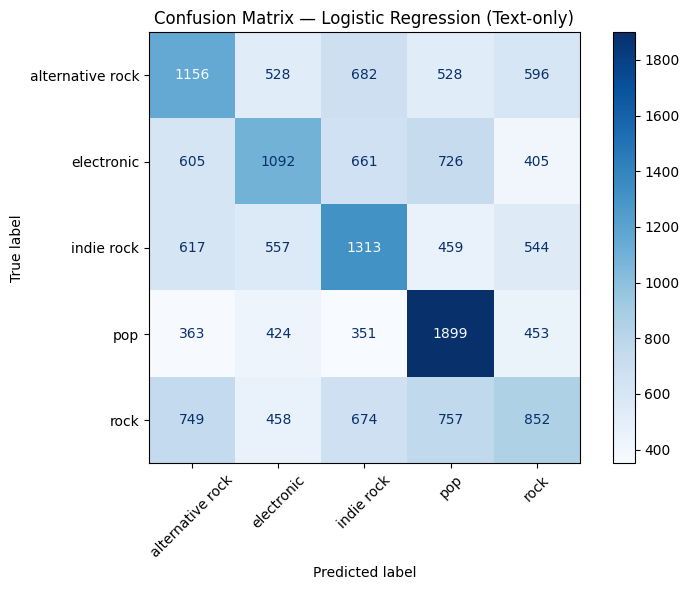

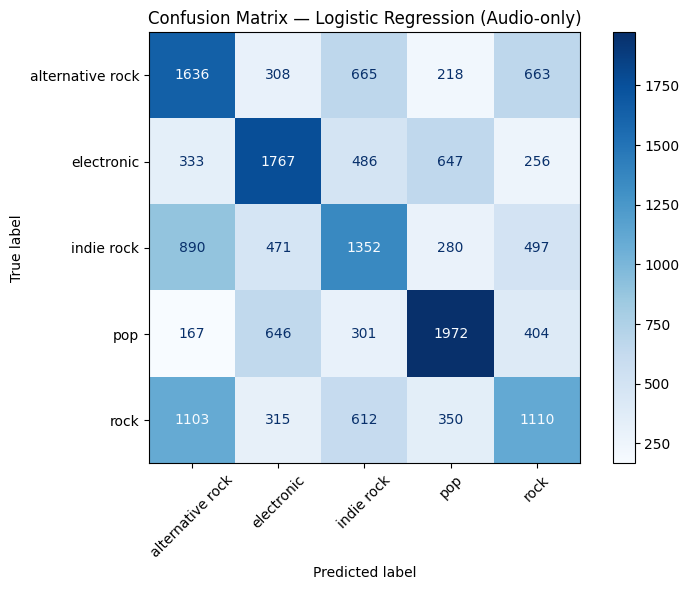

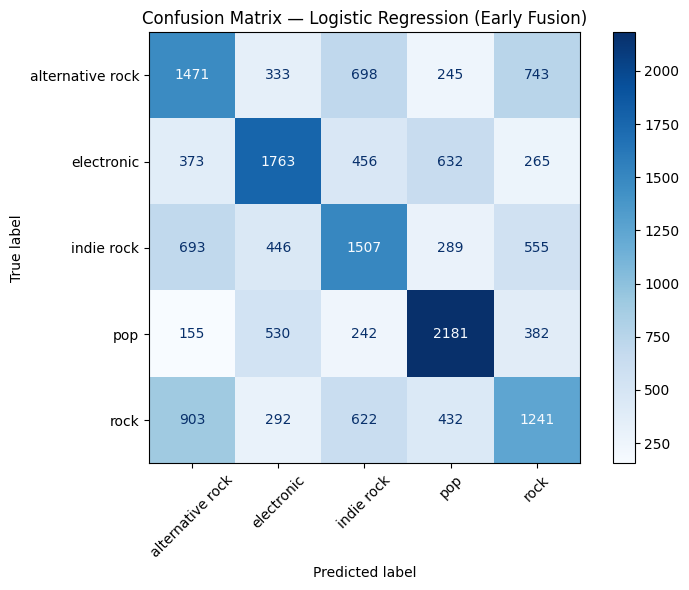

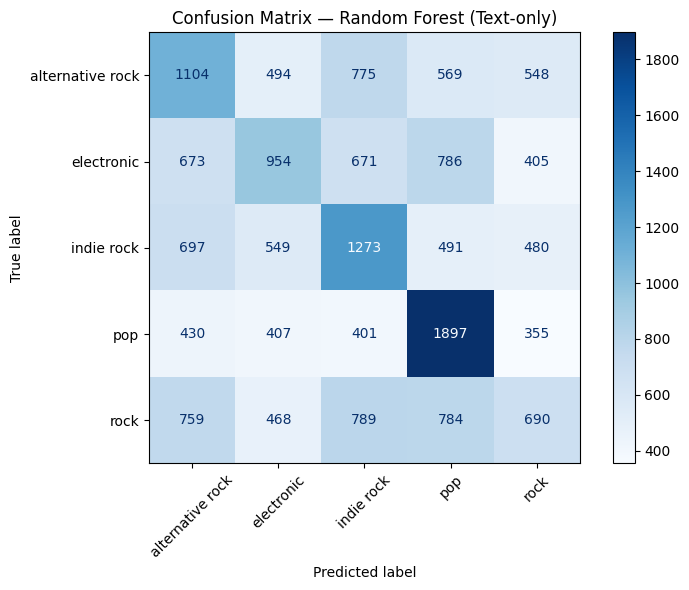

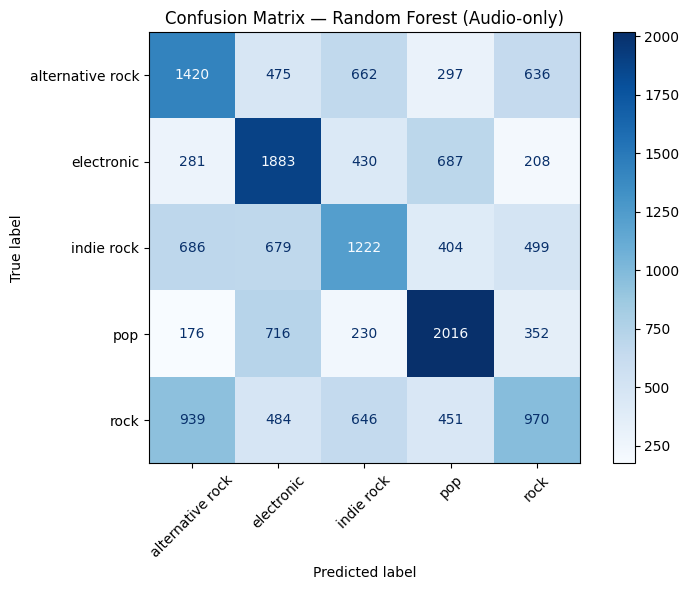

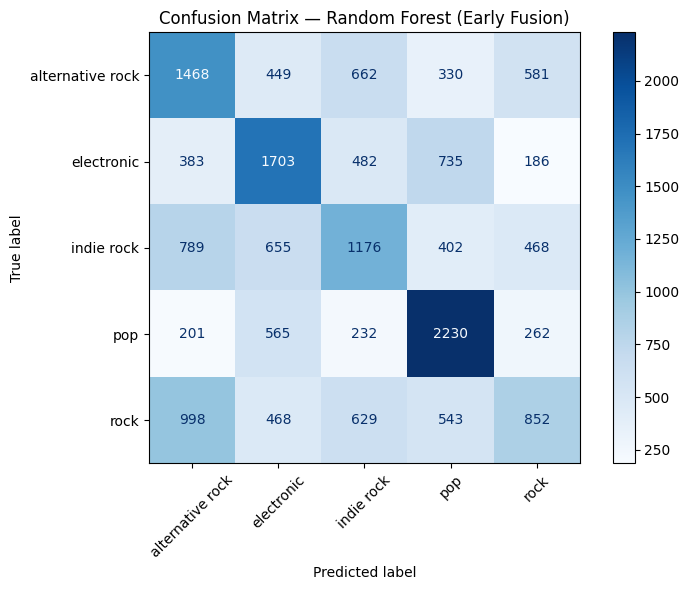

In [30]:
for model_name in [
    "Logistic Regression (Text-only)",
    "Logistic Regression (Audio-only)",
    "Logistic Regression (Early Fusion)",
    "Random Forest (Text-only)",
    "Random Forest (Audio-only)",
    "Random Forest (Early Fusion)"
]:
    preds = cv_predictions[model_name]

    fig, ax = plt.subplots(figsize=(8, 6))

    ConfusionMatrixDisplay.from_predictions(
        preds["y_true"],
        preds["y_pred"],
        display_labels=label_encoder.classes_,
        xticks_rotation=45,
        cmap="Blues",
        ax=ax
    )

    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

## Evaluation Discussion

A methodological detail is important here: although PCA audio embeddings were created once in Part A for exploratory analysis and similarity search, the formal 10-fold cross-validation in Part B uses the raw MFCC statistics. In each fold, missing-value imputation, standardization and PCA are fitted only on the training fold and then applied to the test fold. This avoids unsupervised data leakage from the test fold into the audio representation.

The macro scores across Accuracy, Precision, Recall, and F1 were highly uniform, so there is no benefit in evaluating each metric separately. What this uniformity tells us is that our model is making symmetrical mistakes and does not aggressively pivot towards or ignore one specific genre.

Also, something crucial worth mentioning is the shape of our dataset: we have three different sub-genres of rock (Rock, Indie Rock, and Alternative Rock). Looking at the confusion matrices, a massive portion of the model's errors come from confusing these three with one another. Misclassifying a general rock song as alternative rock is fundamentally less of a mistake than misidentifying it as electronic, proving the model is learning the correct acoustic boundaries even when it misses the exact label.

### Text-only Embeddings
As expected from our previous data analysis, the text-only datasets performed the worst, even though we used a transformer to produce the embeddings. Both Random Forest and Logistic Regression performed poorly, hovering around a 33% to 35% F1-score. This makes sense because a music genre is primarily defined by how it sounds, not by its words. If we look purely at lyrics, even humans (who invented the concept of genres in the first place) would struggle to accurately classify a song. While a score of ~34% is technically 1.7 times better than random guessing (20%), it falls far behind the other approaches.

### Audio-only Embeddings
Here, we see a completely different story: sound is what actually defines the song. While lyrics provide some context, the acoustic features (tempo, instruments, energy) make it much easier to identify the genre. For both Logistic Regression and Random Forest, we see scores jump to around 43% to 45%. This is a massive improvement from the text-only approach and proves that our audio vectors carry the bulk of the predictive power.

### Late vs. Early Fusion
When combining both audio and text data, the models reacted very differently depending on the fusion strategy and the algorithm used:

#### Random Forest
For the Random Forest model, Late Fusion (0.452) significantly outperformed Early Fusion (0.417). This reveals a known weakness of tree-based models: when we combined the hundreds of audio and text features into one giant vector (Early Fusion), the Random Forest likely struggled with the high dimensionality and "noise" of the text data, causing it to lose accuracy. However, by using Late Fusion—allowing one tree to judge purely on audio, another to judge purely on text, and simply averaging their final votes—the model achieved its best score.

#### Logistic Regression
Logistic Regression showed the exact opposite behavior. Early Fusion (0.466) was the absolute best performer across all experiments, slightly edging out Late Fusion (0.46). Because Logistic Regression is a linear model, it handles high-dimensional vectors beautifully. By fusing the text and audio arrays together before training (Early Fusion), the model was able to mathematically weigh specific words against specific sounds simultaneously, capturing the complete "vibe" of the song better than any other approach.

### Audio vs. Text
Note. The results here are from the Logistic Regression model. Both Random Forest and Logistic Regression exhibit the same behavior, but the exact numbers differ.

Although the Audio-only model is superior overall, the confusion matrices reveal that each modality is naturally better at predicting different genres:

#### The Dominance of Audio (Electronic and Alternative Rock) 
Audio dominates genres defined by instrumentation. The Audio-only model excelled in "Electronic" (1767 correct vs. 1092 for Text) and "Alternative Rock" (1636 vs. 1156). It successfully leveraged clear acoustic signals, like synthesizers, heavy basslines, and distorted guitars—which carry much stronger predictive power than lyrics.

#### Hidden Strength of Text (Pop and Indie Rock) 
Conversely, Text-only embeddings thrived in genres with distinct lyrical formulas. In "Pop," text kept close pace with audio (1899 vs. 1972 correct for audio), effectively capturing highly specific vocabulary and recurring themes. The same pattern can be observed for "Indie Rock" (1313 vs. 1352 correct for audio), proving that its thematic signature is easier for a model to isolate than its overlapping acoustic features.

### Conclusion
This contrast perfectly explains why Logistic Regression with Early Fusion achieved the highest overall score (0.466). It successfully combines both modalities, relying on audio vectors to classify instrumental-heavy tracks, while leaning on text vectors to lock down lyrically distinct genres.

# 4. K-Means clustering

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import math

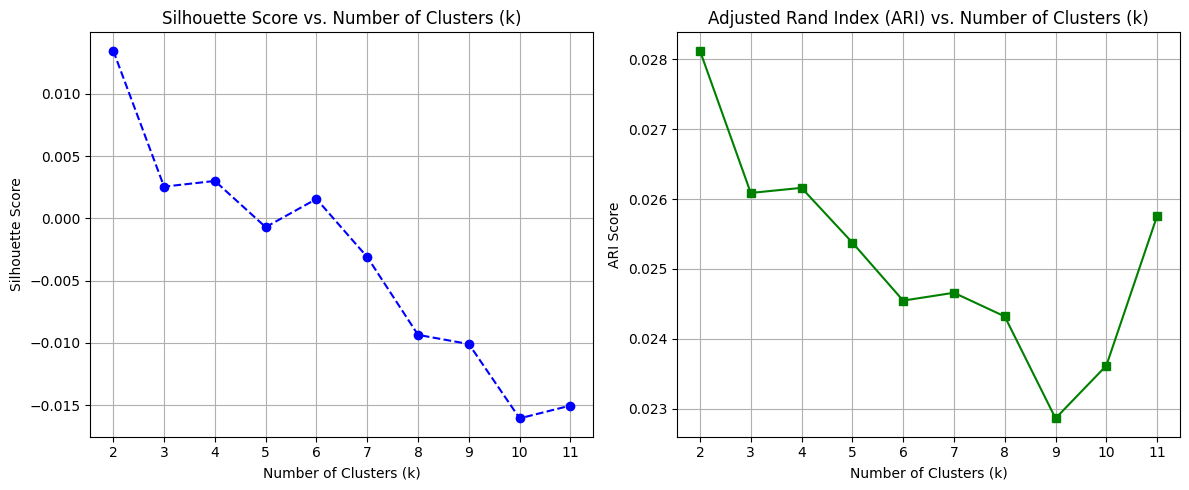

Optimal 'k' based on highest Silhouette Score: 2
Adjusted Rand Index (ARI) at optimal k=2: 0.0281


In [ ]:
text_features = text_embeddings_df.values 
audio_features = audio_embeddings_df.values
true_labels = labels_df["genre"].values # We need this for the ARI metric!

scaler_text = StandardScaler()
scaler_audio = StandardScaler()

bert_scaled = scaler_text.fit_transform(text_features)
audio_scaled = scaler_audio.fit_transform(audio_features)

# Apply the dimension-balancing weight to the audio
audio_weight = math.sqrt(bert_scaled.shape[1] / audio_scaled.shape[1]) 
weighted_audio = audio_scaled * audio_weight

# Fuse them together into the final combined vector
X_fused = np.hstack((bert_scaled, weighted_audio))

k_values = range(2, 12) 
silhouette_scores = []
ari_scores = [] 

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_fused)
    
    sil_score = silhouette_score(X_fused, cluster_labels)
    silhouette_scores.append(sil_score)
    
    ari = adjusted_rand_score(true_labels, cluster_labels)
    ari_scores.append(ari)

plt.figure(figsize=(12, 5))

# Left Plot: Silhouette Score
plt.subplot(1, 2, 1)
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title("Silhouette Score vs. Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)

# Right Plot: Adjusted Rand Index (ARI)
plt.subplot(1, 2, 2)
plt.plot(k_values, ari_scores, marker='s', linestyle='-', color='g')
plt.title("Adjusted Rand Index (ARI) vs. Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("ARI Score")
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

best_k_idx = np.argmax(silhouette_scores)
best_k = k_values[best_k_idx]
best_ari = ari_scores[best_k_idx]

print(f"Optimal 'k' based on highest Silhouette Score: {best_k}")
print(f"Adjusted Rand Index (ARI) at optimal k={best_k}: {best_ari:.4f}")

## Why K-means fails
To understand why K-means fails to form meaningful clusters, we must look at our baseline: human-defined music genres. While a listener instantly recognizes the "vibe" of a country song, its raw audio waves and lyrics might mathematically look completely different from another song in that exact same genre.
Unsupervised models like K-means do not learn the way a supervised model (like Logistic Regression or Random Forest) does. K-means cannot adjust the weights of specific words or audio trends; it simply groups data based on raw vector distances, completely missing the cultural context. Two songs featuring an acoustic guitar might look mathematically identical to K-means, even if human listeners perceive them as entirely different genres.
Finally, the metrics tell the physical story of the data. The fact that K=2 performed "best"—combined with a Silhouette Score near zero—proves that K-means sees our dataset as one dense, highly overlapping cloud of points. As was evident in our previous scatter plots, there are no natural, empty spaces between genres for K-means to find. That is why unsupervised learning is ill-suited for this task and it is best to pivot to supervised learning.